# AirNow and UFS-CHEM

Our first example will demonstrate the basics available in MELODIES MONET to 
compare the meteorological capabilities of UFS-CHEM results against AirNow surface observations. We will analyze variables including ozone, temperature, windspeed, and wind direction.

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "control_ufschem-example.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2017-07-01-00:00:00',
  'end_time': '2017-07-03-00:00:00',
  'output_dir': './output/airnow_ufschem',
  'debug': True},
 'model': {'ufschem_v1': {'files': 'example:ufschem:2017-07',
   'files_surf': 'example:ufschem:2017-07_sfc',
   'mod_type': 'ufs',
   'is_global': True,
   'mod_kwargs': {'surf_only': True,
    'sfc_varlist': ['tmp2m', 'spfh2m', 'ugrd10m', 'vgrd10m']},
   'radius_of_influence': 100000,
   'extra_calc': {'rel_hum': {'pres_calc': 'surfpres_pa',
     'specific_hum': 'spfh2m',
     'temp_calc': 'tmp2m'},
    'windspeed': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'},
    'winddir': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'},
    'wind_barb': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'},
    'rose_plot': {'model_wdir': 'winddir', 'model_wspd': 'windspeed'}},
   'mapping': {'airnow': {'o3': 'OZONE',
     'tmp2m': 'TEMP',
     'windspeed': 'WS',
     'rel_hum': 'RHUM'}},
   'projection': None,
   'plot_kwargs': {'color': 'magenta', 'marker': 's', 'li

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='control_ufschem-example.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2017-07-01 00:00:00'),
    end_time=Timestamp('2017-07-03 00:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/airnow_ufschem',
    output_dir_save='./output/airnow_ufschem',
    output_dir_read='./output/airnow_ufschem',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

ufs
example:ufschem:2017-07


**** Reading UFS-AQM or UFS-Chem model output...


/home/rschwantes/miniconda3/envs/melodies-monet-pandas2/lib/python3.11/site-packages/monetio/models/ufs.py:219: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  xr.open_mfdataset(fname, concat_dim="time", combine="nested", **kwargs)


Performing extra model calculations...
Calculating modeled relative humidity...
Calculating modeled windspeed...
Calculating modeled wind direction...


Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [7]:
an.models['ufschem_v1'].obj

<xarray.Dataset> Size: 320MB
Dimensions:        (time: 72, z: 1, y: 192, x: 384)
Coordinates:
  * time           (time) datetime64[ns] 576B 2017-07-01T01:00:00 ... 2017-07-04
  * y              (y) float64 2kB 89.28 88.36 87.42 ... -87.42 -88.36 -89.28
  * x              (x) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
    latitude       (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    longitude      (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
Dimensions without coordinates: z
Data variables: (12/14)
    o3             (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    temperature_k  (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfpres_pa    (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    dp_pa          (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfalt_m      (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    dz_m           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ...             ...
    spfh2m         (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ugrd10m        (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    vgrd10m        (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    rel_hum        (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    windspeed      (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    winddir        (time, z, y, x) float32 21MB 243.3 244.2 ... 352.7 351.9
Attributes:
    grid:         gaussian
    grid_id:      1
    hydrostatic:  non-hydrostatic
    im:           384
    jm:           192
    ncnsto:       139
    source:       FV3GFS
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...
    ak:           [0. 0.]
    bk:           [0.99467119 1.        ]
    history:      Fri Feb 27 09:53:22 2026: ncrcat 20170701_dynf001.nc 201707...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [8]:
an.open_obs()

Performing extra calculations for obs...


In [9]:
an.obs

{'airnow': observation(
     obs='airnow',
     label='airnow',
     file='example:airnow:2017-07',
     obj=...,
     extra_calc={'rose_plot': {'obs_wdir': 'WD', 'obs_wspd': 'WS'}},
     type='pt_src',
     sat_type=None,
     sat_method=None,
     data_proc=None,
     variable_dict={'OZONE': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Ozone (ppbv)', 'xlabel_plot': 'Ozone (ppbv)', 'vmin_plot': 0.0, 'vmax_plot': 80, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'TEMP': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature 2m (K)', 'xlabel_plot': 'Temperature 2m (K)', 'vmin_plot': 275, 'vmax_plot': 320, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'WS': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed 10m (m/s)', 'xlabel_plot': 'Windspeed 10m (m/s)', 'vmin_plot': 0, 'vmax_plot': 10, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'WD': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value'

In [10]:
an.obs['airnow'].obj

<xarray.Dataset> Size: 18MB
Dimensions:     (time: 49, y: 1, x: 1934)
Coordinates:
  * time        (time) datetime64[ns] 392B 2017-07-01 ... 2017-07-03
  * x           (x) int64 15kB 0 1 2 3 4 5 6 ... 1928 1929 1930 1931 1932 1933
    siteid      (x) <U9 70kB ...
    latitude    (x) float64 15kB ...
    longitude   (x) float64 15kB ...
Dimensions without coordinates: y
Data variables: (12/30)
    BARPR       (time, y, x) float64 758kB ...
    BC          (time, y, x) float64 758kB ...
    CO          (time, y, x) float64 758kB ...
    NO          (time, y, x) float64 758kB ...
    NO2         (time, y, x) float64 758kB ...
    NO2Y        (time, y, x) float64 758kB ...
    ...          ...
    utcoffset   (y, x) int64 15kB ...
    cmsa_name   (y, x) float64 15kB ...
    msa_code    (y, x) float64 15kB ...
    msa_name    (y, x) <U52 402kB ...
    state_name  (y, x) <U2 15kB ...
    epa_region  (y, x) <U5 39kB ...

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [11]:
%%time

an.pair_data()

1, in pair data
After pairing:              time  BARPR  BC  CO   NO  NO2  NO2Y  NOX  NOY  OC  ...  \
0     2017-07-01    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
1     2017-07-01    NaN NaN NaN  0.0  1.0   NaN  NaN  NaN NaN  ...   
2     2017-07-01    NaN NaN NaN  0.0  1.0   NaN  NaN  NaN NaN  ...   
3     2017-07-01    NaN NaN NaN  0.0  0.0   NaN  NaN  NaN NaN  ...   
4     2017-07-01    NaN NaN NaN  1.0  NaN   NaN  NaN  NaN NaN  ...   
...          ...    ...  ..  ..  ...  ...   ...  ...  ...  ..  ...   
94761 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
94762 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
94763 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
94764 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   
94765 2017-07-03    NaN NaN NaN  NaN  NaN   NaN  NaN  NaN NaN  ...   

        longitude         o3       tmp2m  windspeed    rel_hum   surfpres_pa  \
0      -60.364400        NaN         NaN       

In [12]:
an.paired

{'airnow_ufschem_v1': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='airnow',
     model='ufschem_v1',
     model_vars=['o3', 'tmp2m', 'windspeed', 'rel_hum'],
     obs_vars=['OZONE', 'TEMP', 'WS', 'RHUM'],
     filename='airnow_ufschem_v1.nc',
 )}

In [13]:
an.paired['airnow_ufschem_v1']

pair(
    type='pt_sfc',
    radius_of_influence=1000000.0,
    obs='airnow',
    model='ufschem_v1',
    model_vars=['o3', 'tmp2m', 'windspeed', 'rel_hum'],
    obs_vars=['OZONE', 'TEMP', 'WS', 'RHUM'],
    filename='airnow_ufschem_v1.nc',
)

## MELODIES-MONET now contains several meteorological capabilities 

In addition to previous capabilites and plots, users can now:

* Specify wind barbs
    * Note: users may experience longer wait times if they wish to plot wind barbs
* Create rose plots for pollution and wind speed
    * Rose plots can be aggregated across scales (e.g. EPA region and CONUS)
* Create boxplots on given intervals for any of the supported meteorological variables 
* Mark statistical significance on boxplots


## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

**NOTE:** That AirNow data for calm wind sets windspeed = 0 and wind direction = 0. In the wind-rose plots, calm winds are plotted as an inner circle for wind direction and data is removed for pollution rose plots based on the threshold set in your yaml file. 

All other plots, it's up to the user on what to consider for these calm winds. Plots below and corresponding yaml file demonstrates how to remove all calm winds from the calculation for the timeseries plots (second set of plots plot_grp1a) and the spatial overlay plots (second set of plots plot_grp3a). Additional processing and consideration for calm winds is under development.

/home/rschwantes/MONET/v1.1/test_examples/MELODIES-MONET/melodies_monet/plots/surfplots.py:1592: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=text_kwargs['fontsize']*0.8)


Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.OZONE.2017-07-01_00.2017-07-03_00.state_name.MI...


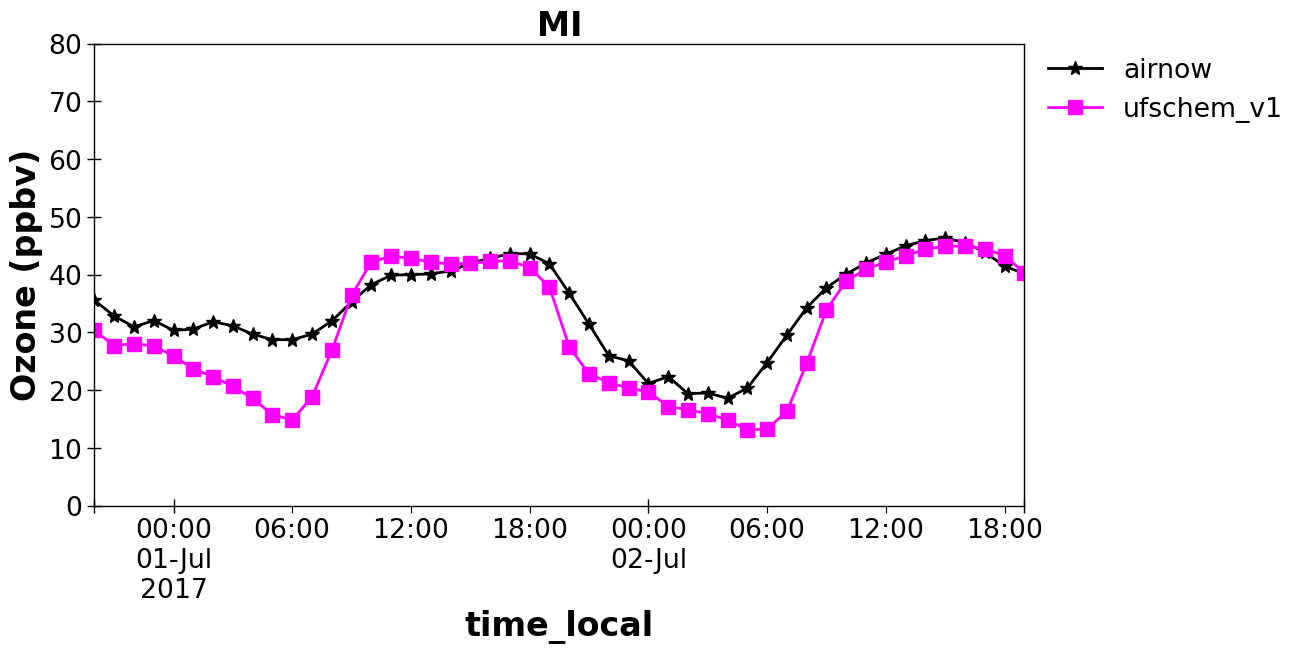

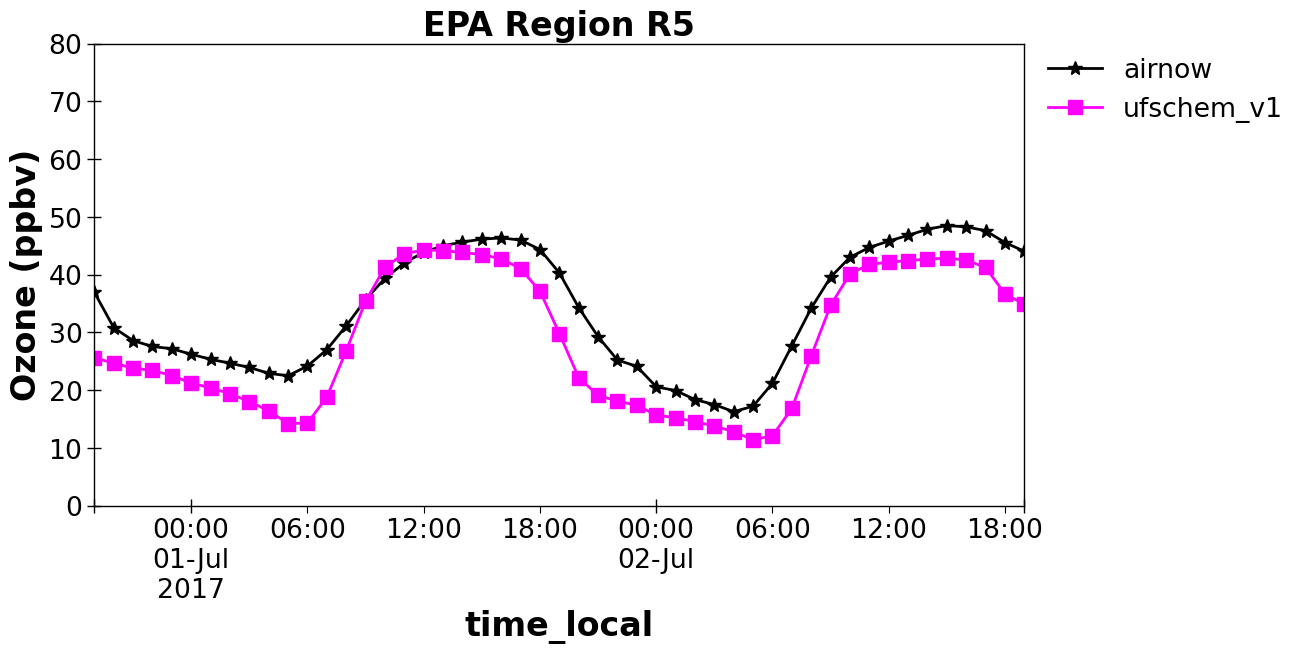

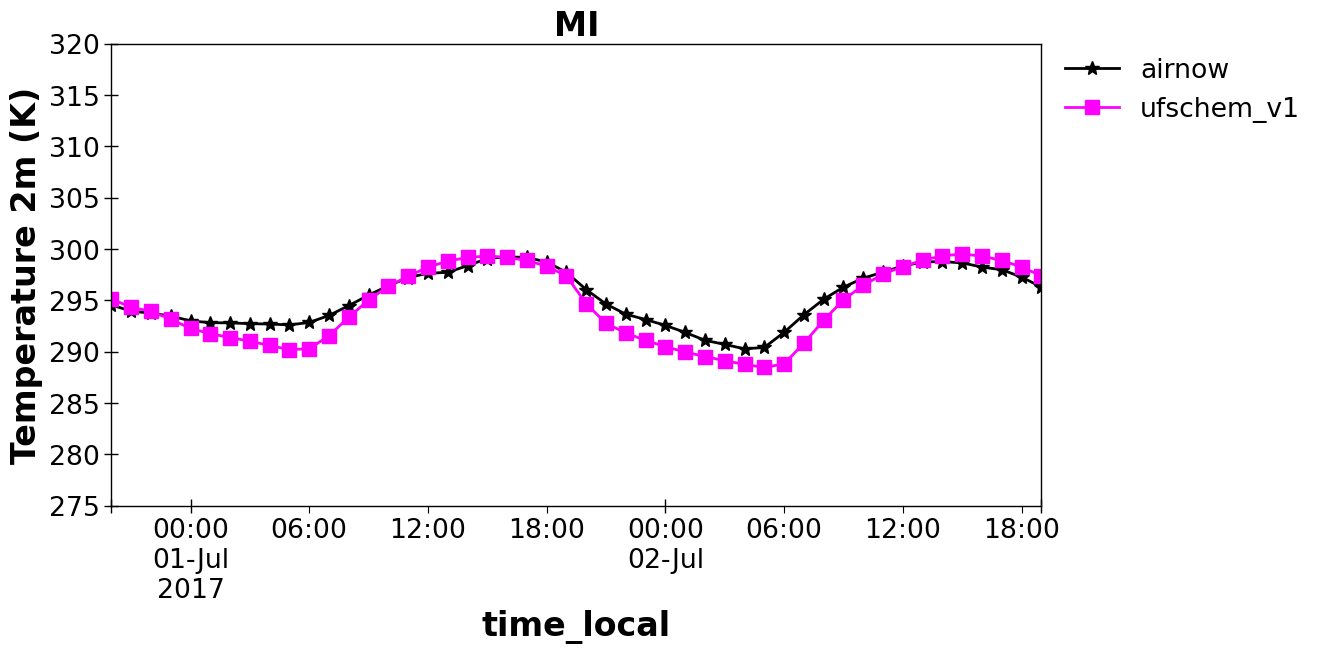

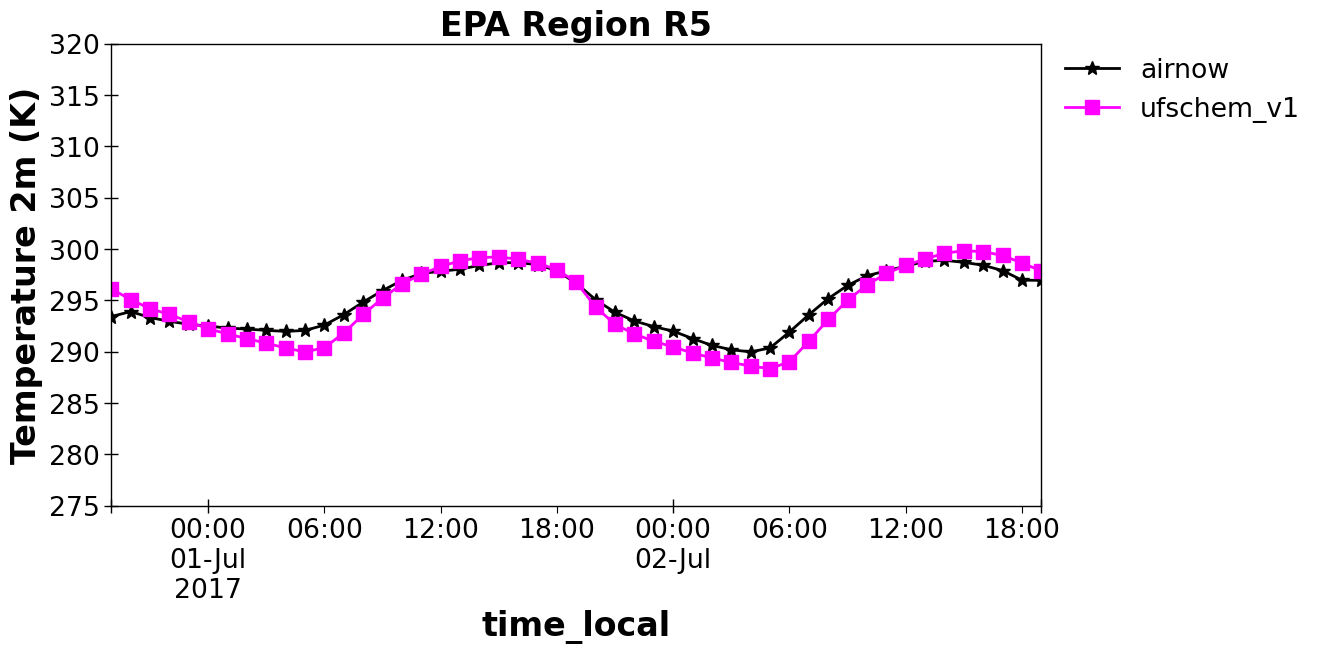

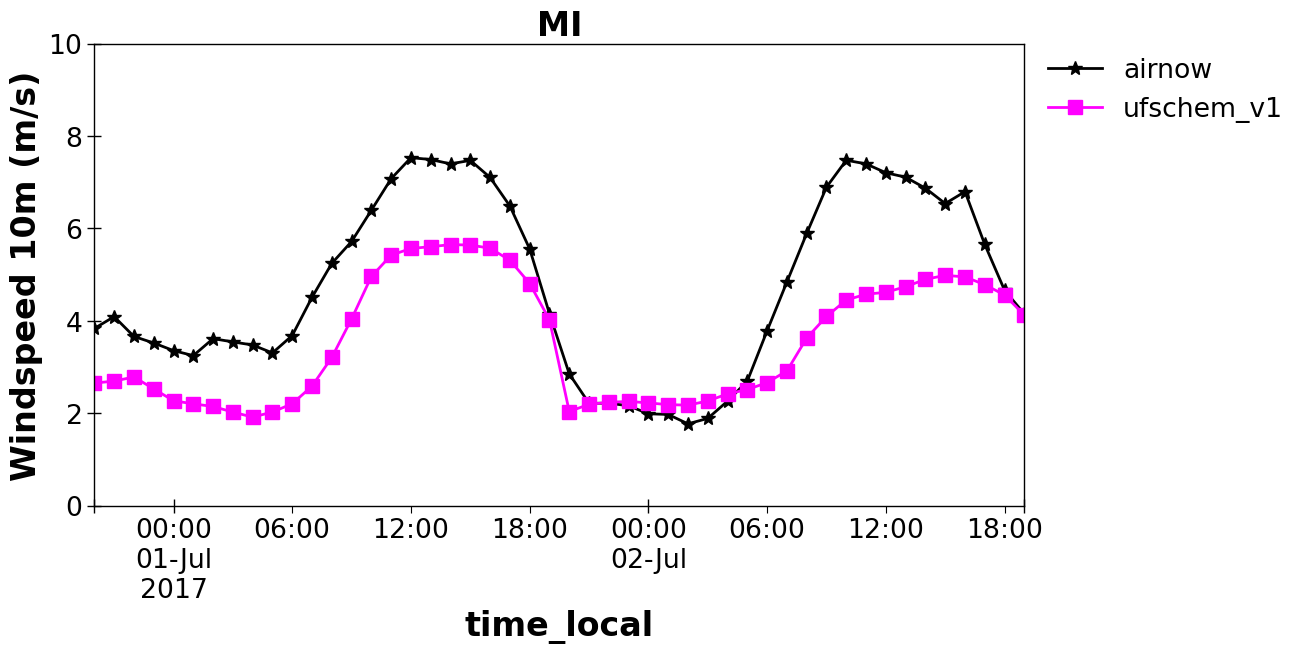

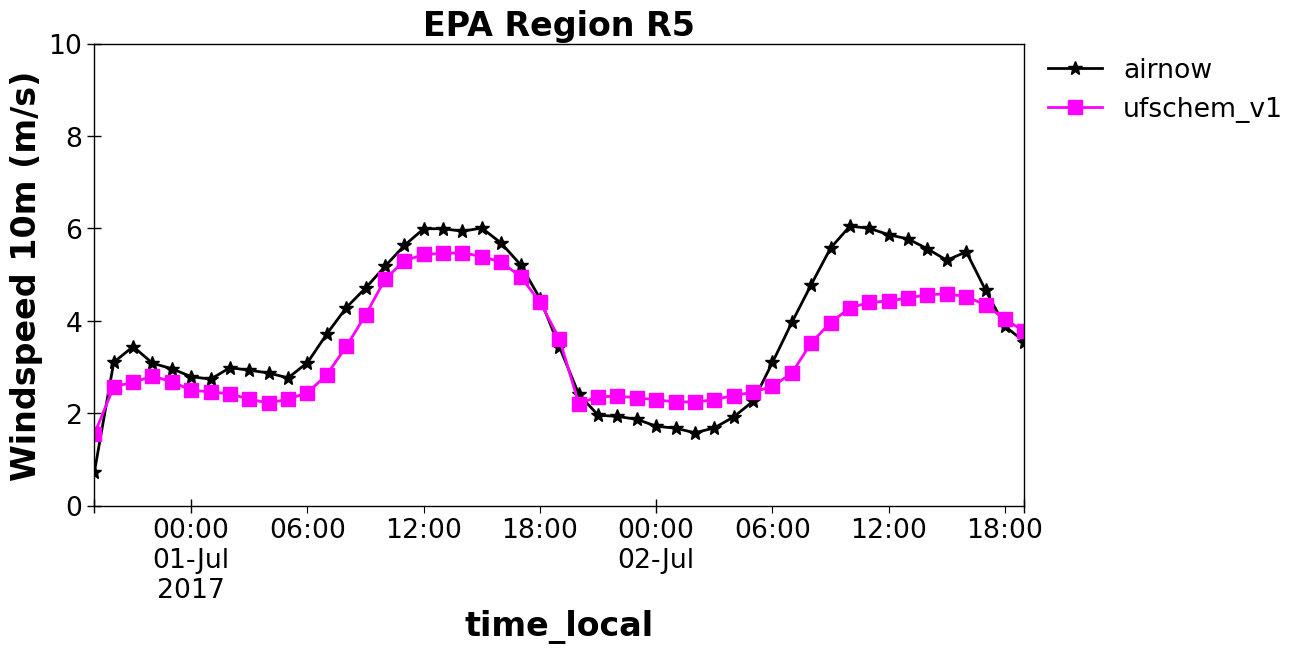

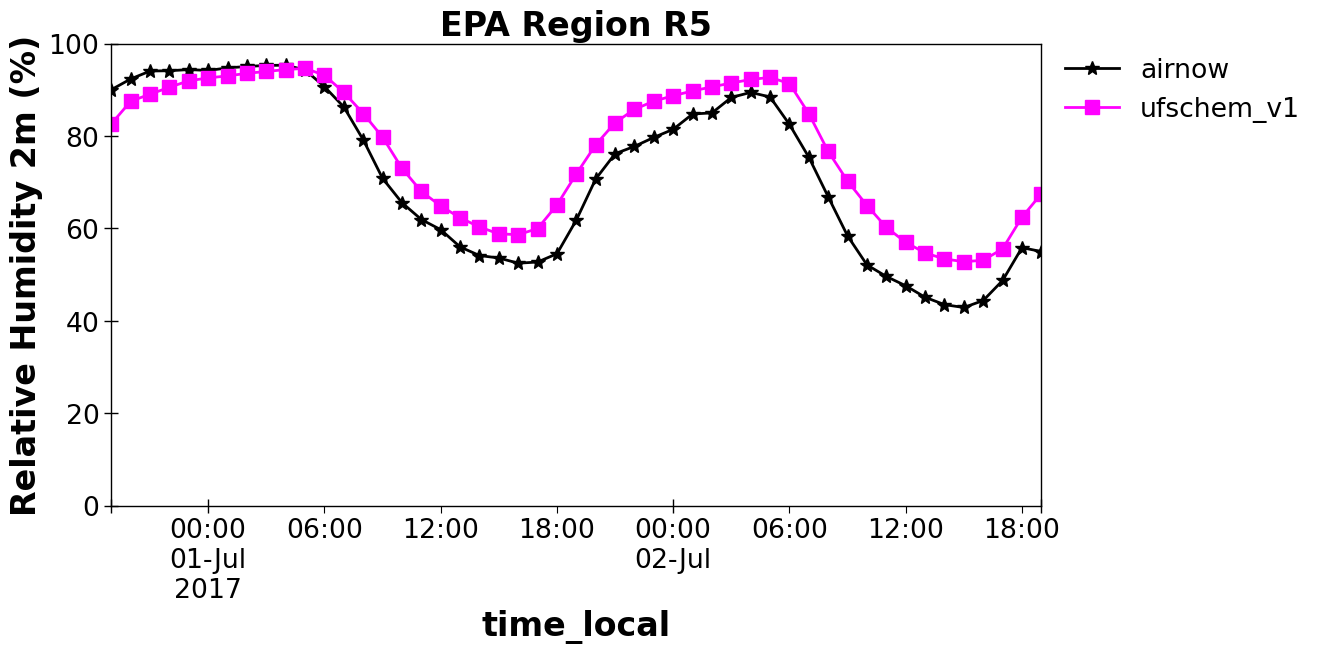

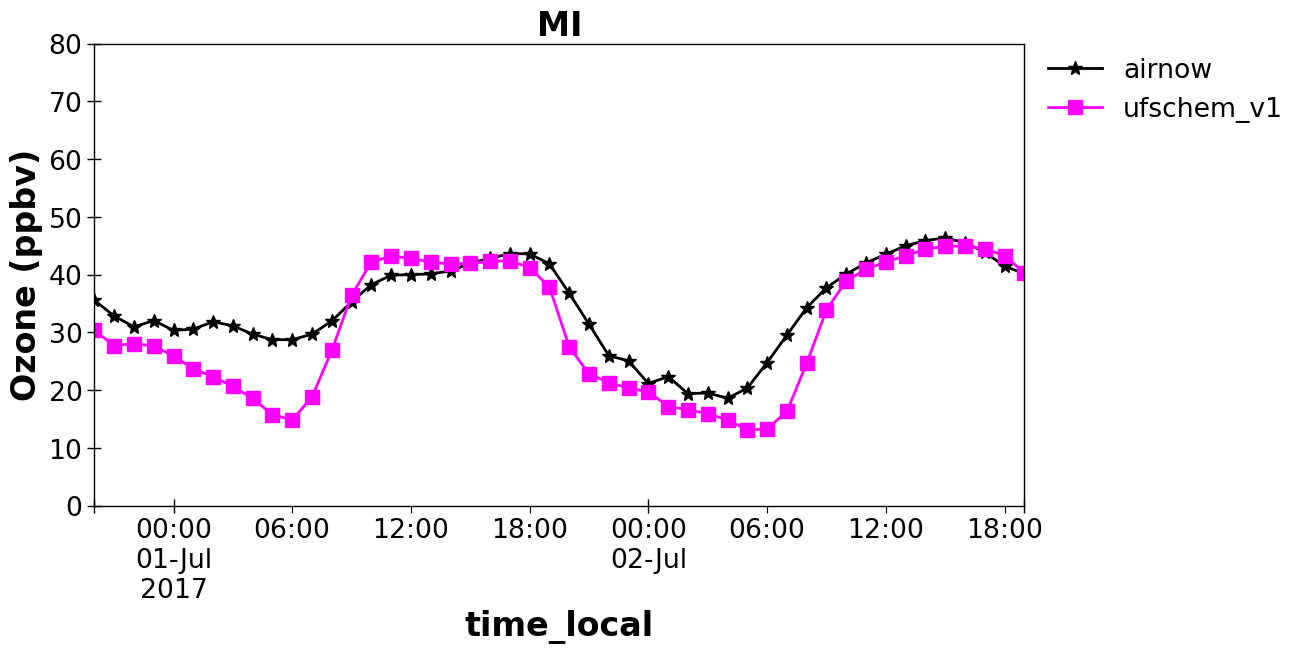

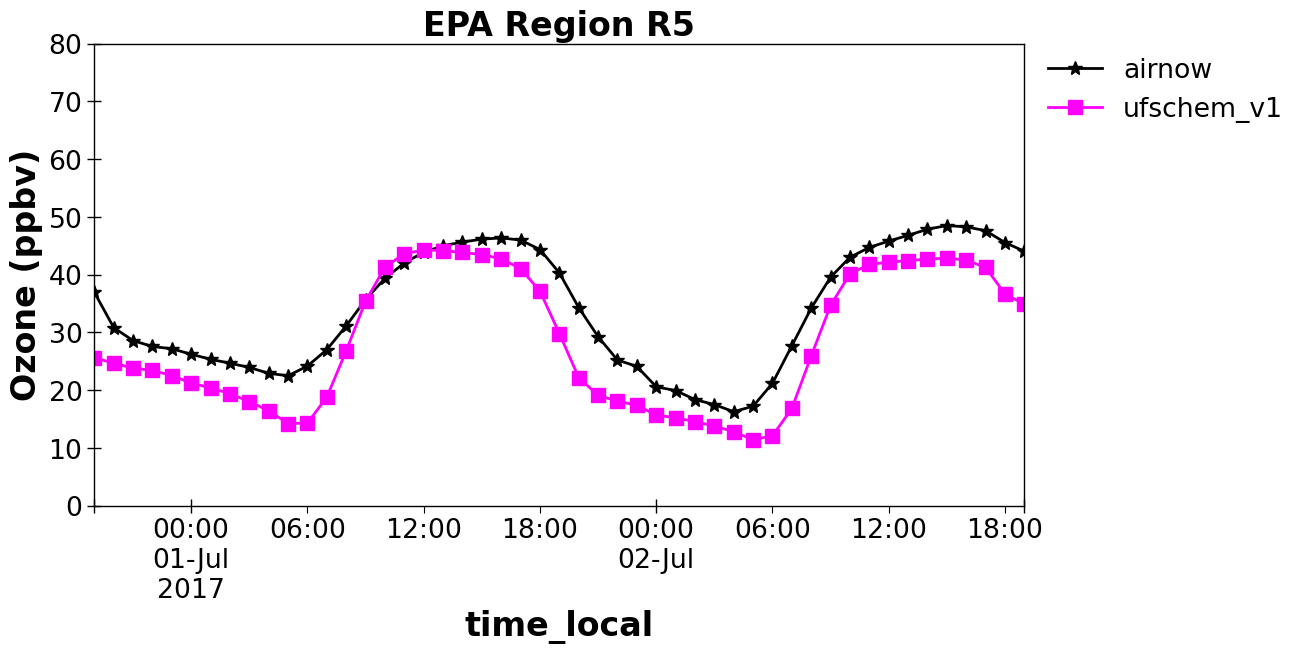

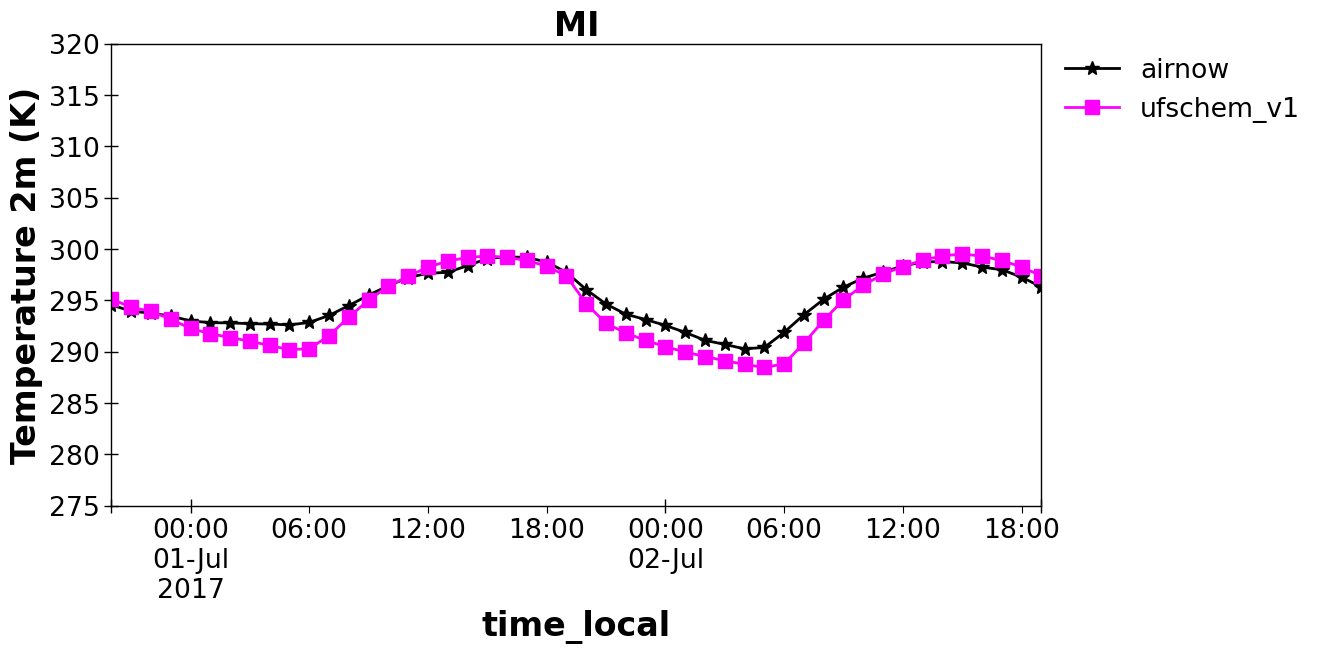

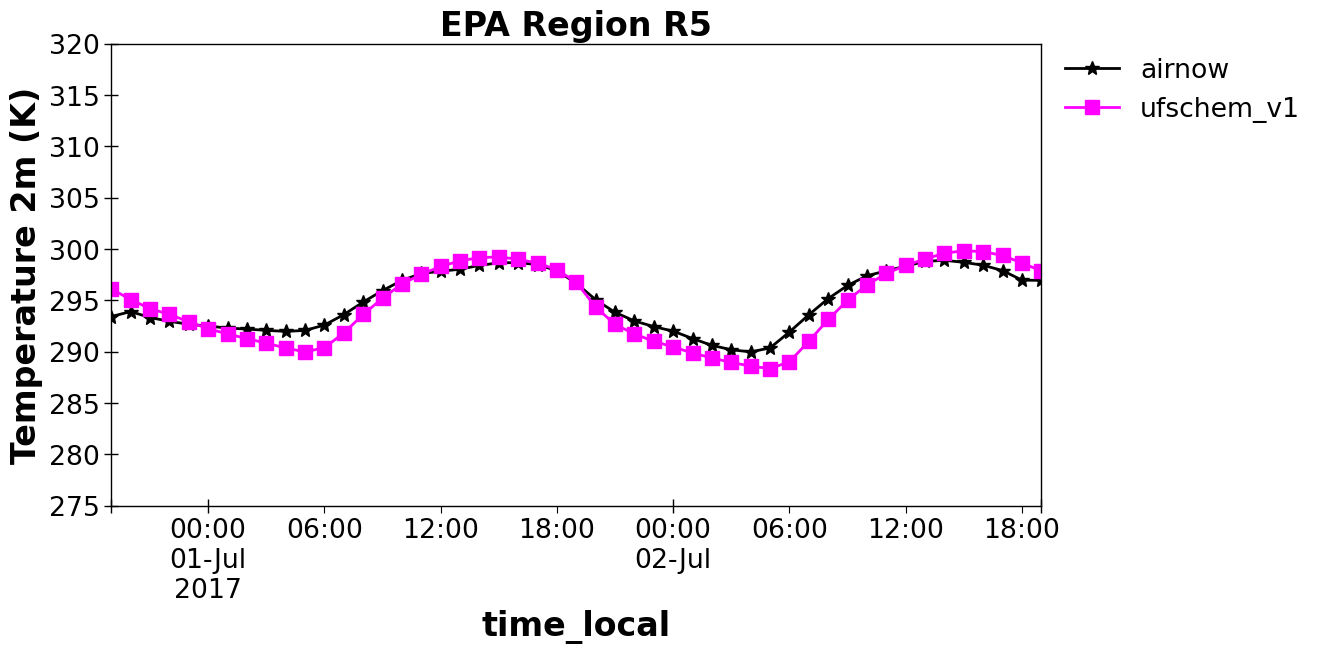

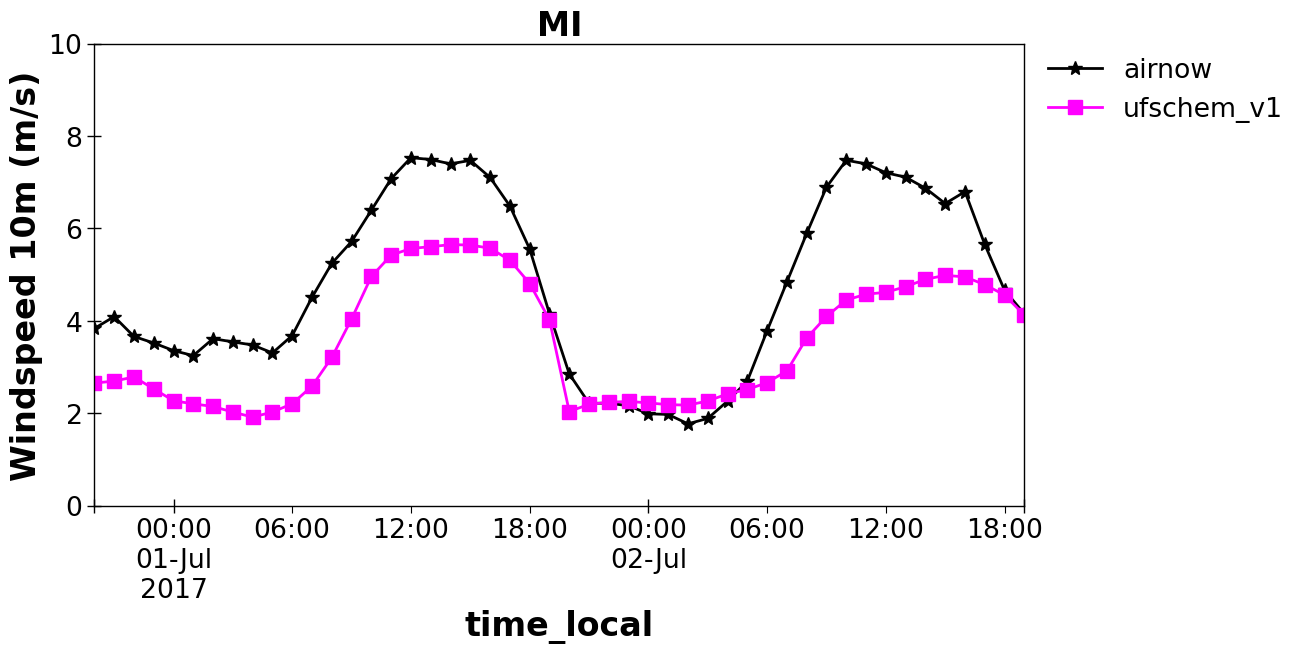

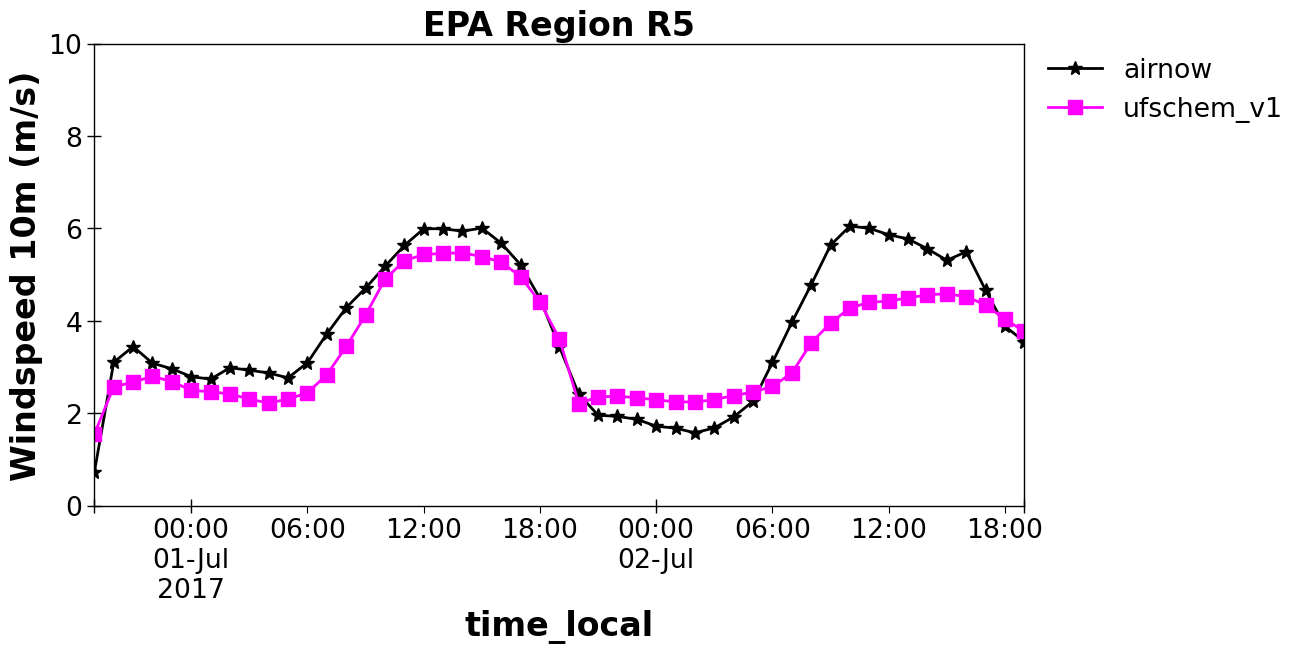

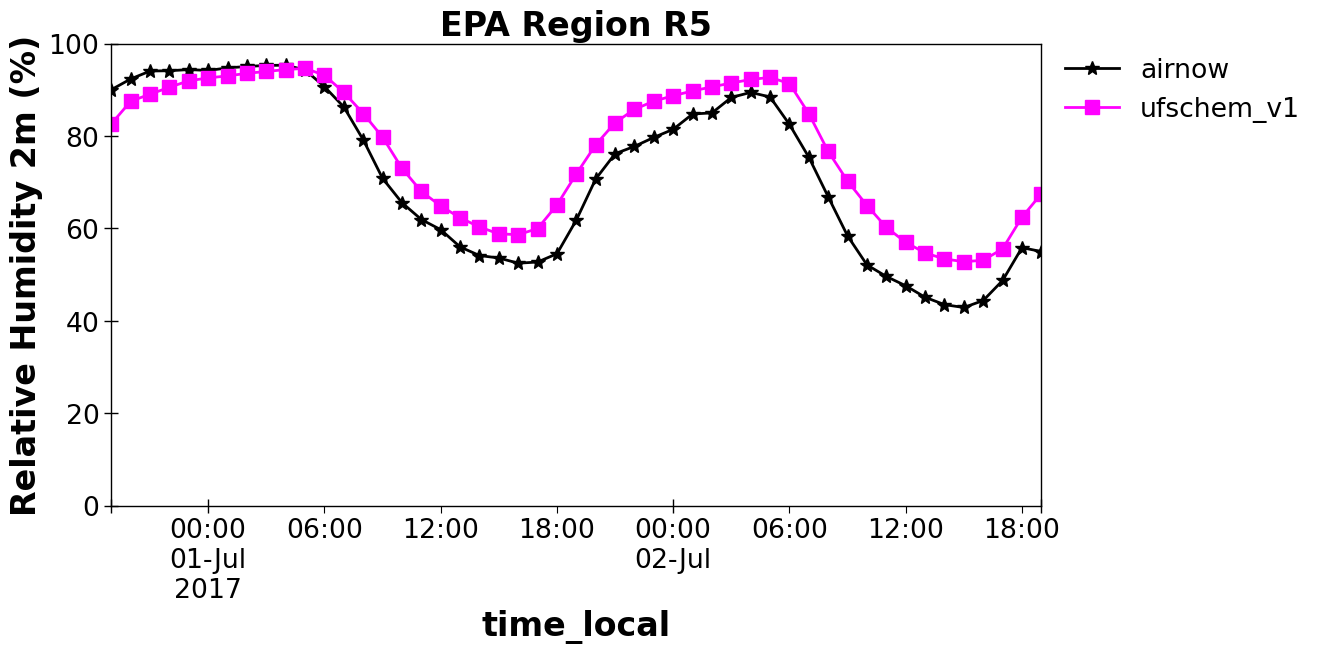

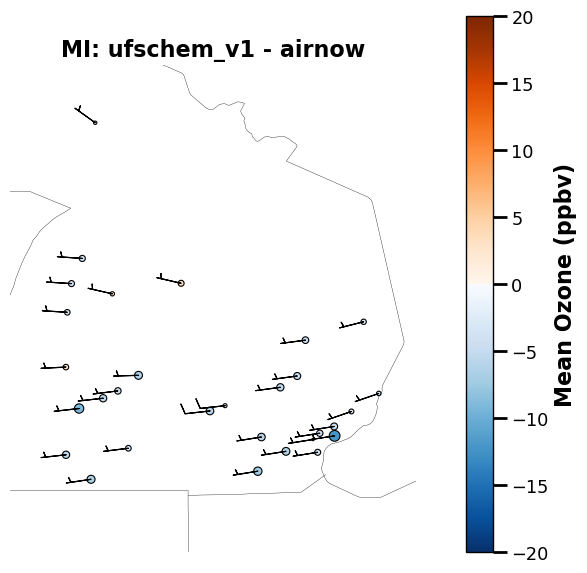

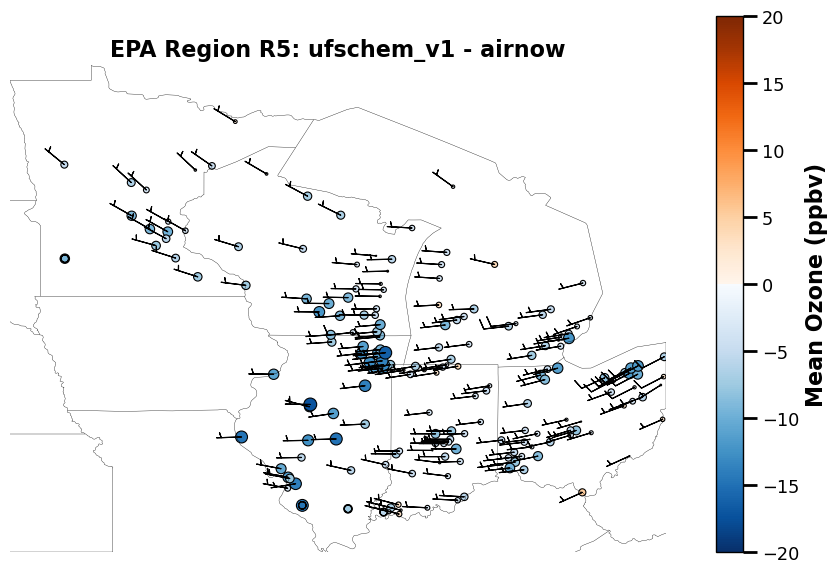

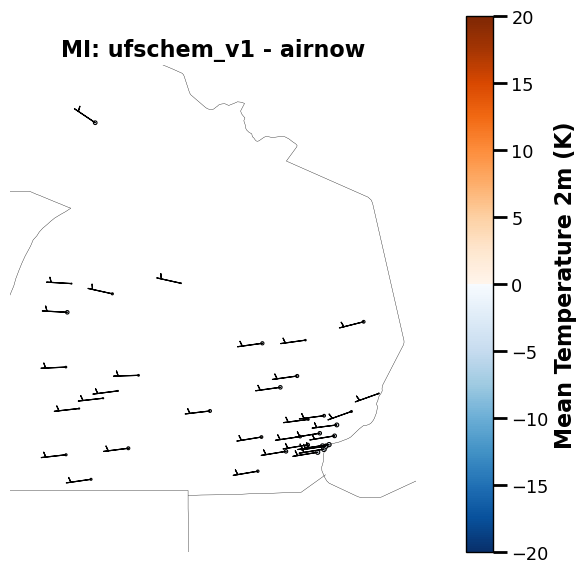

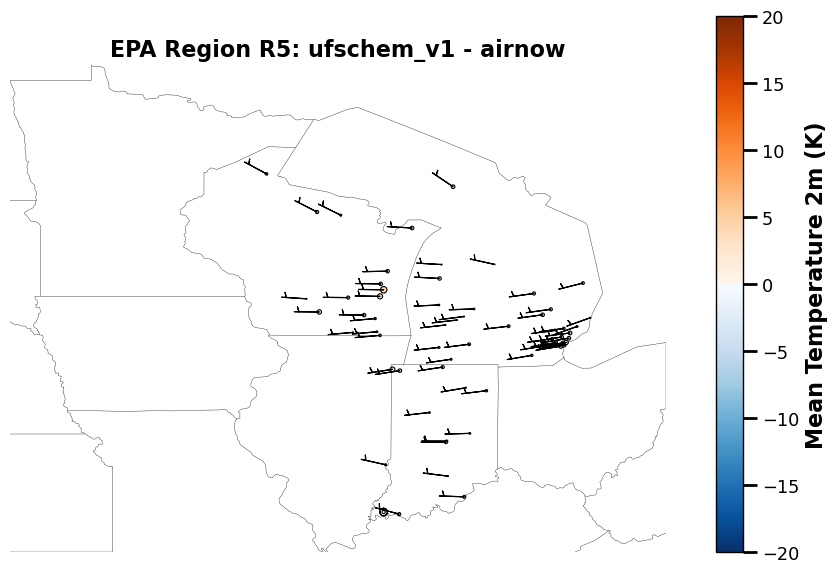

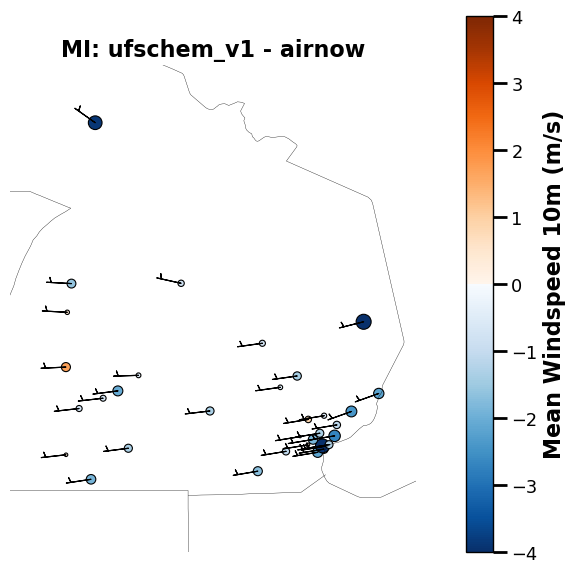

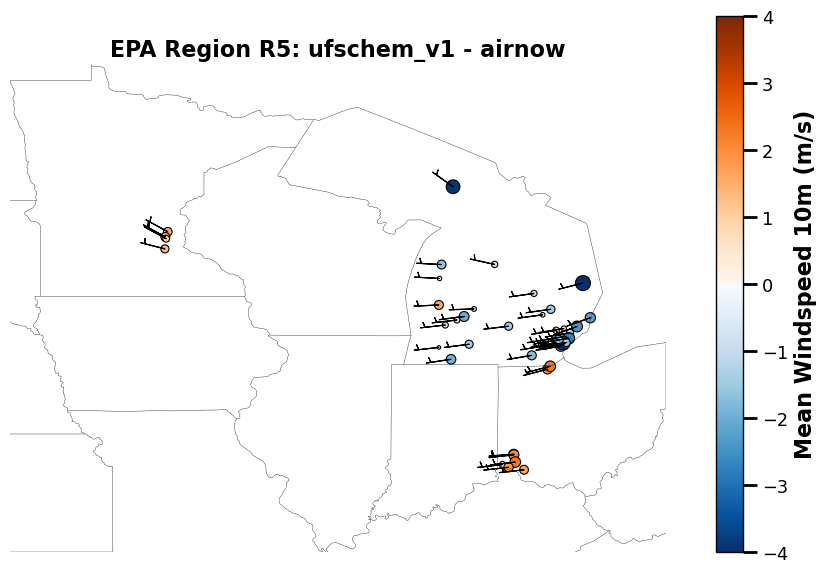

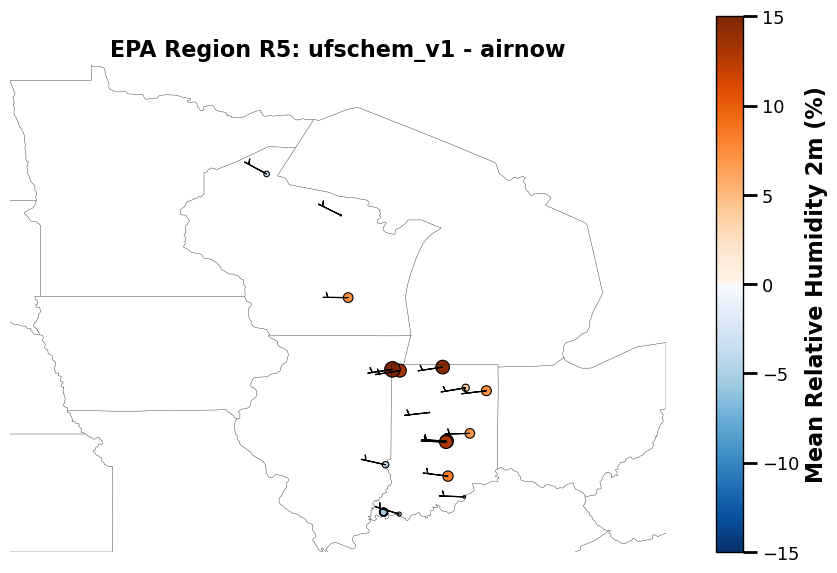

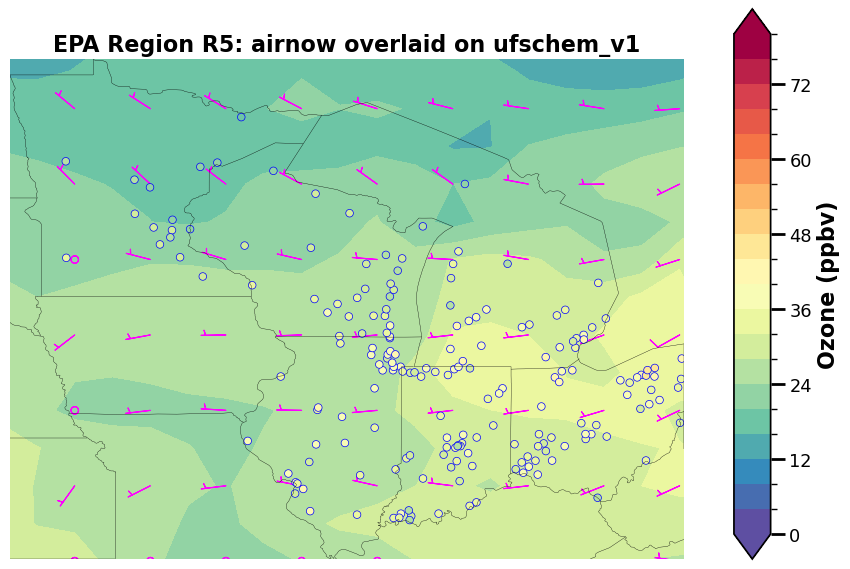

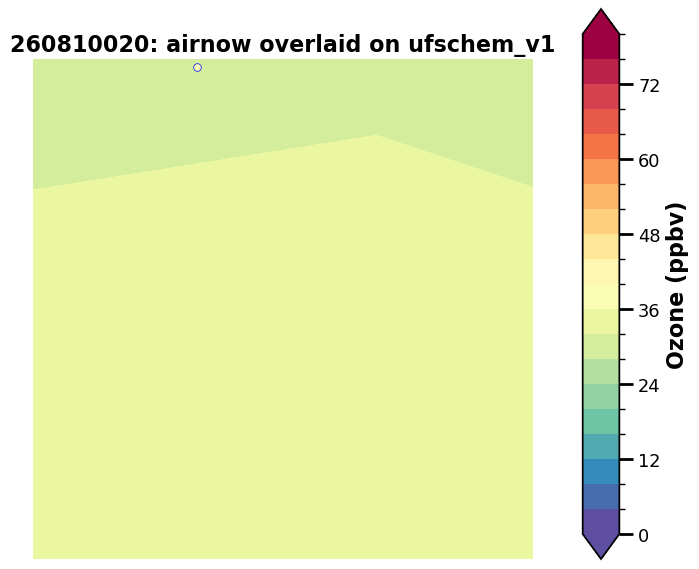

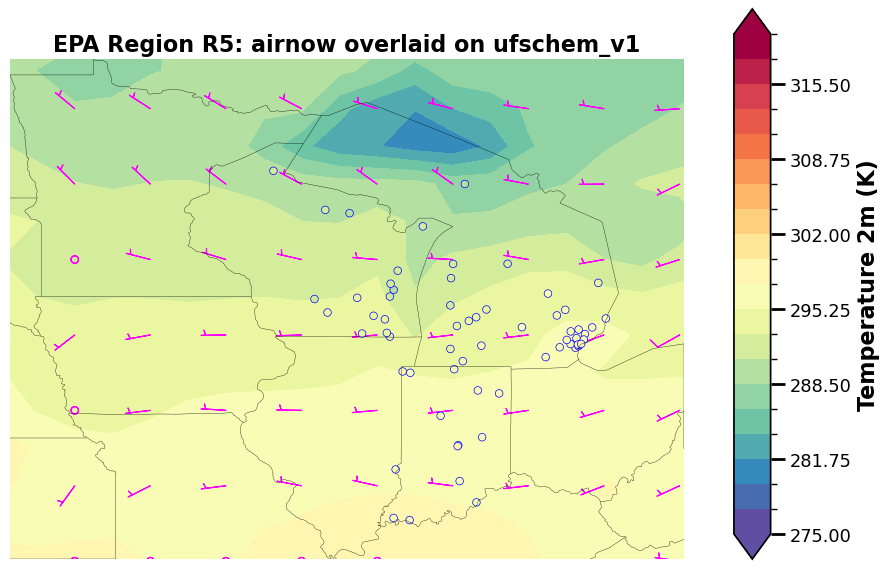

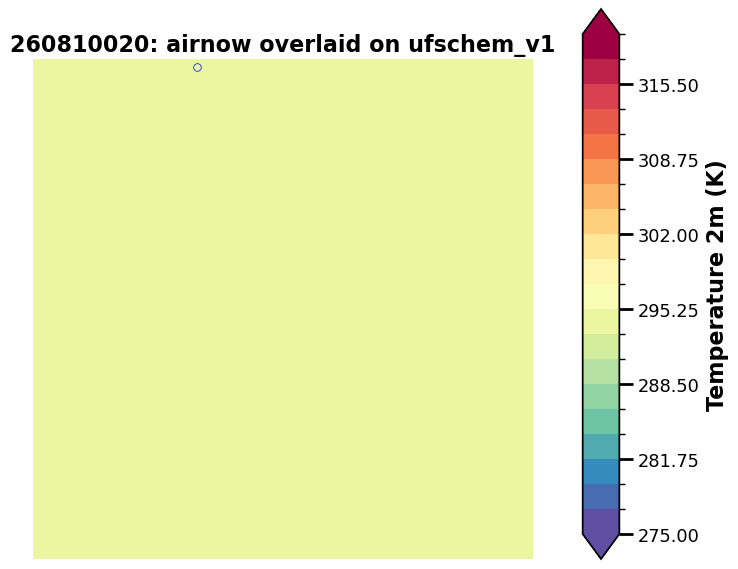

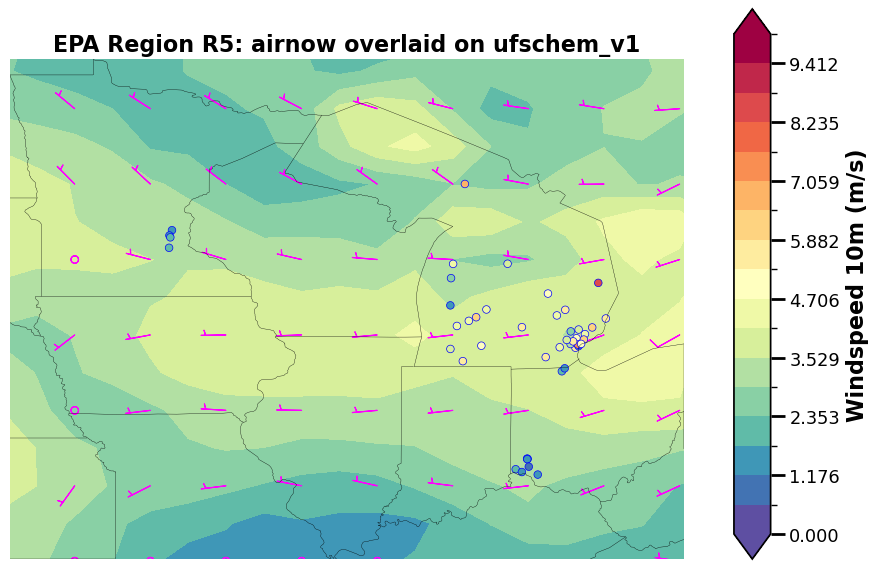

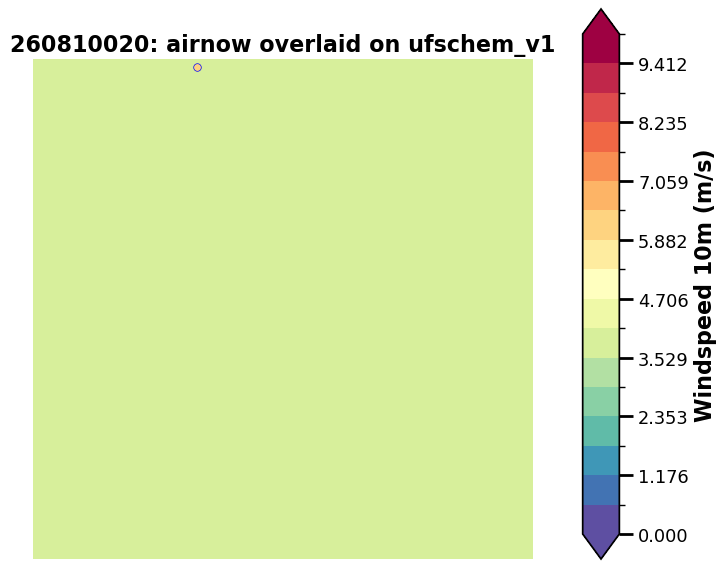

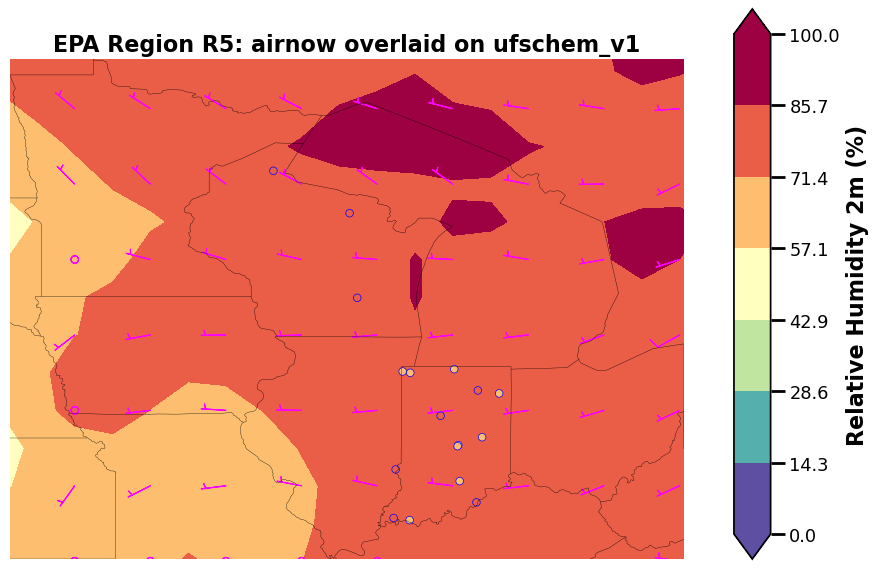

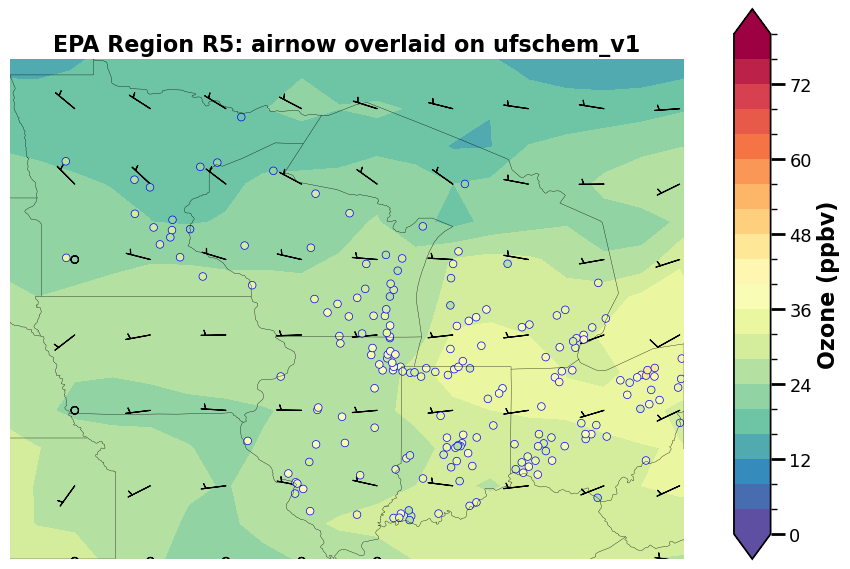

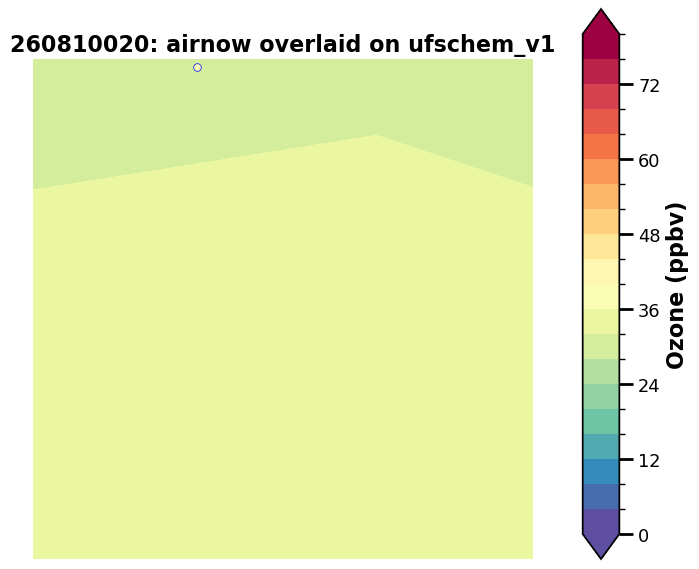

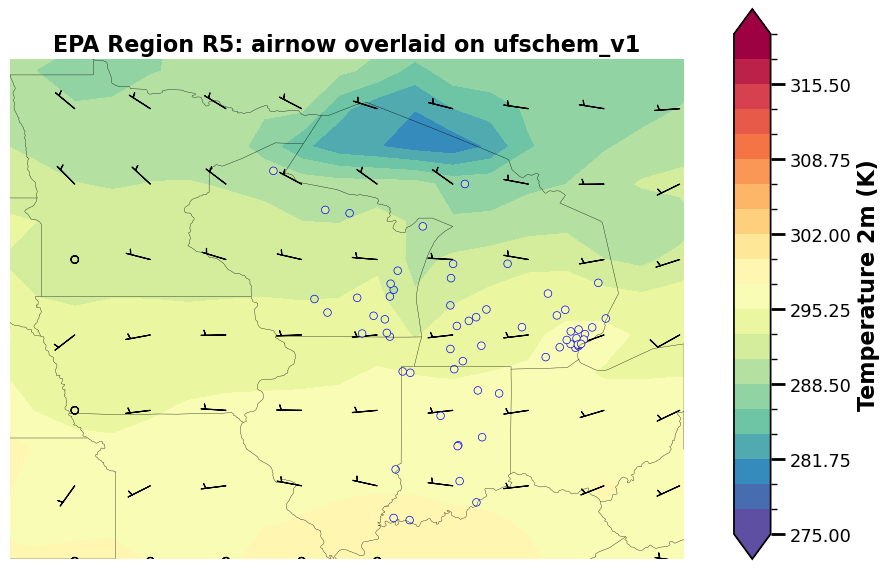

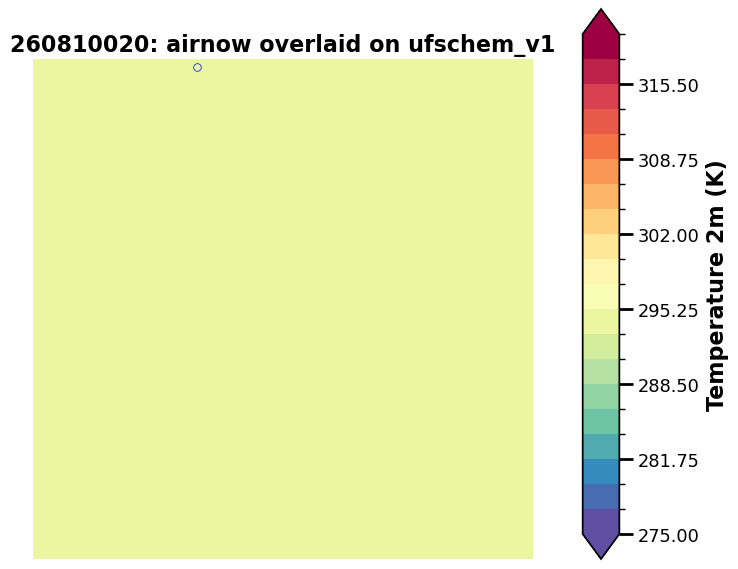

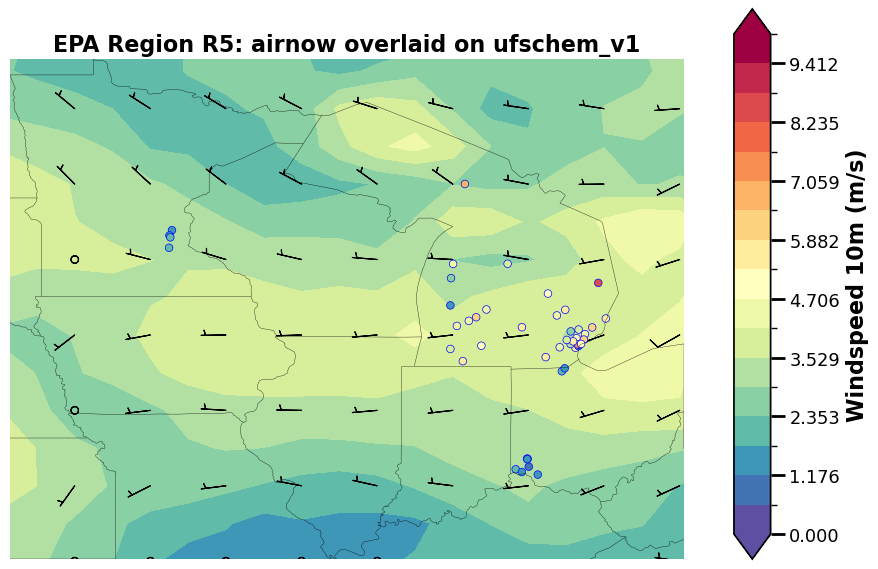

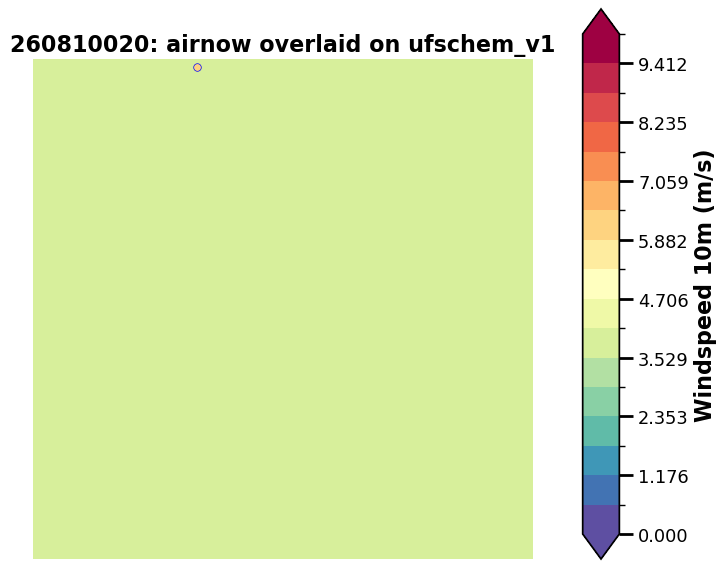

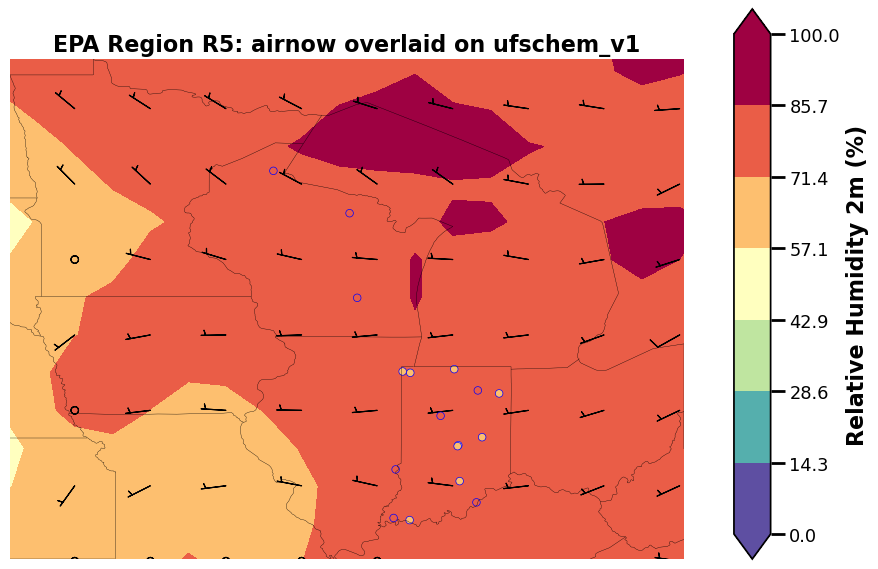

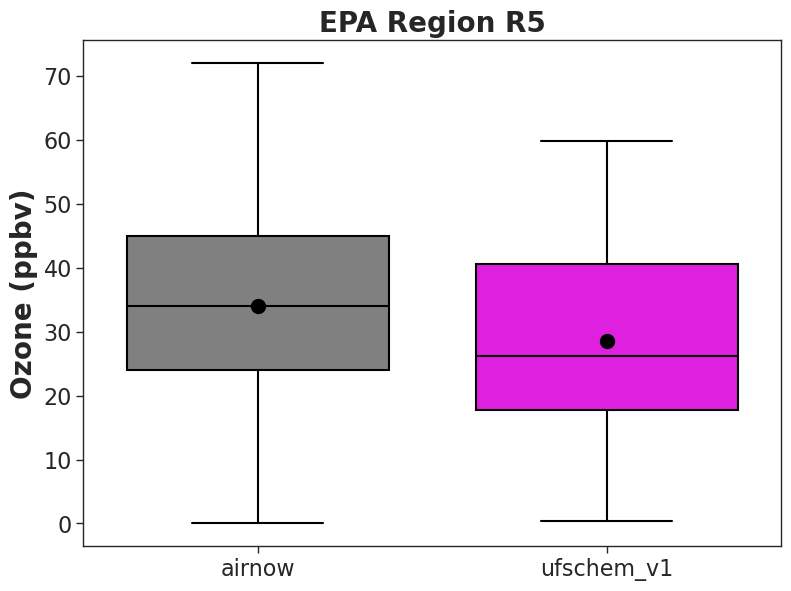

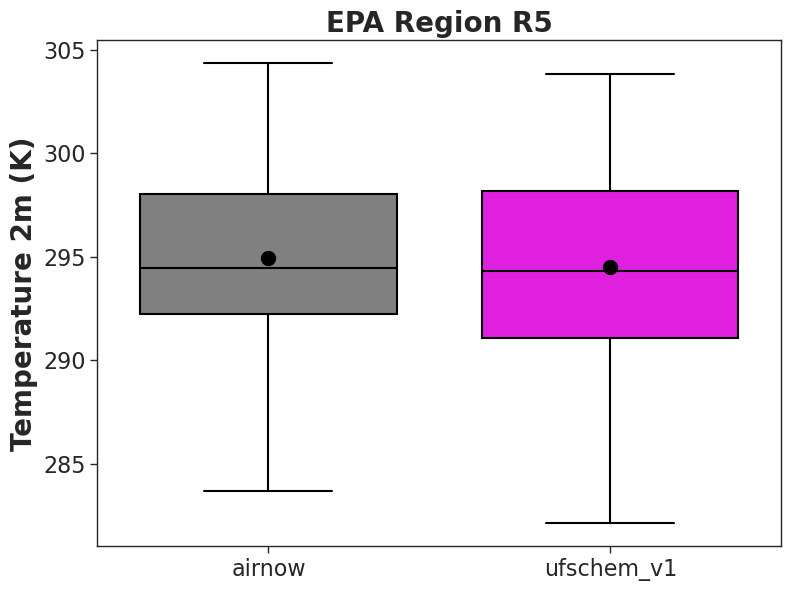

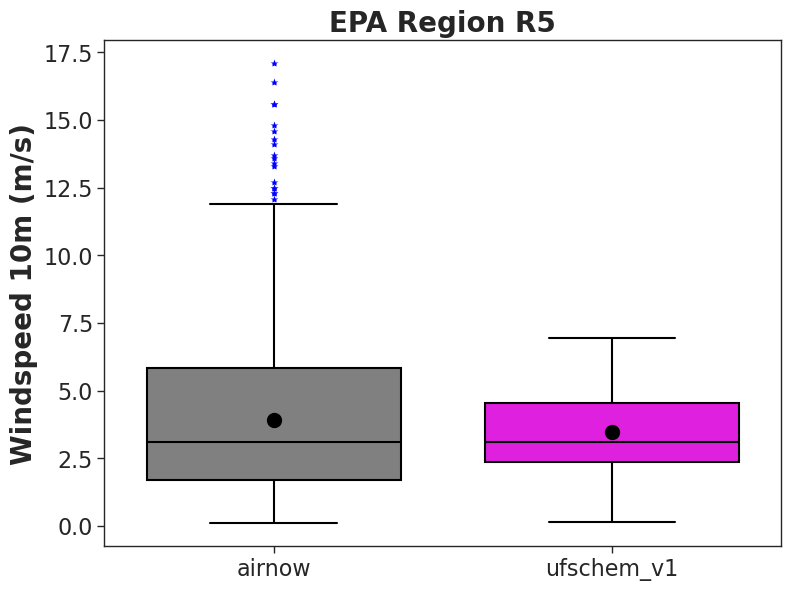

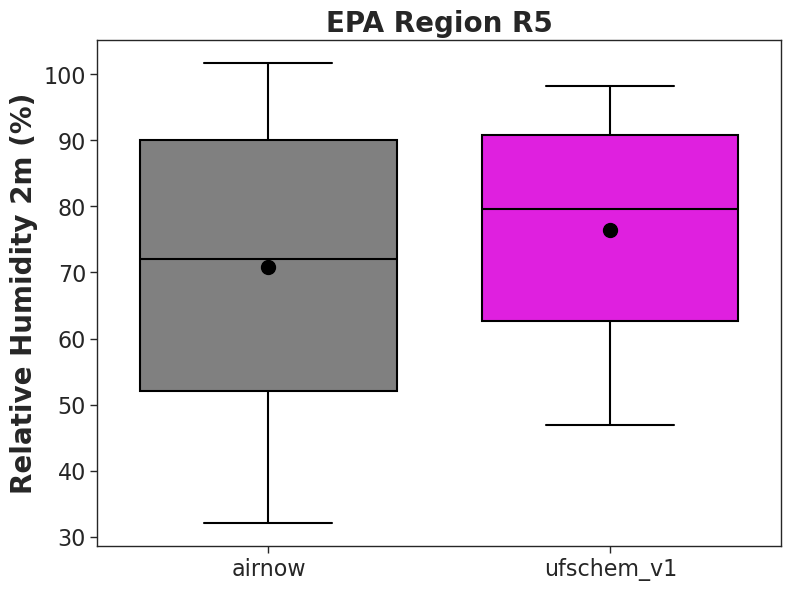

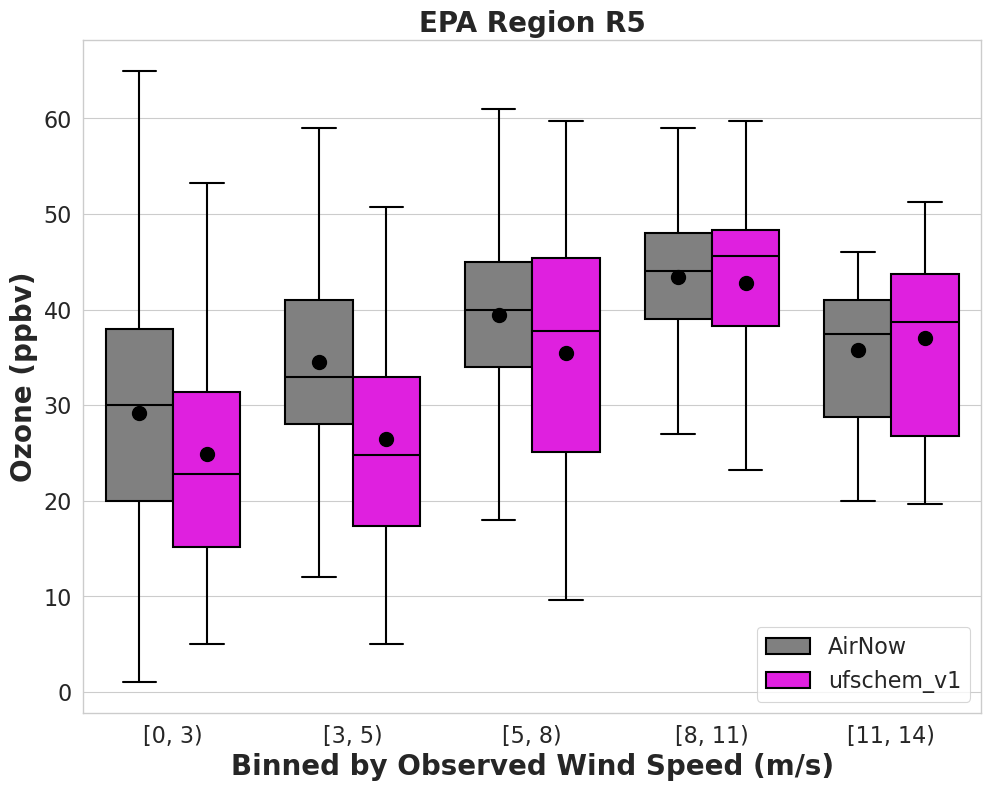

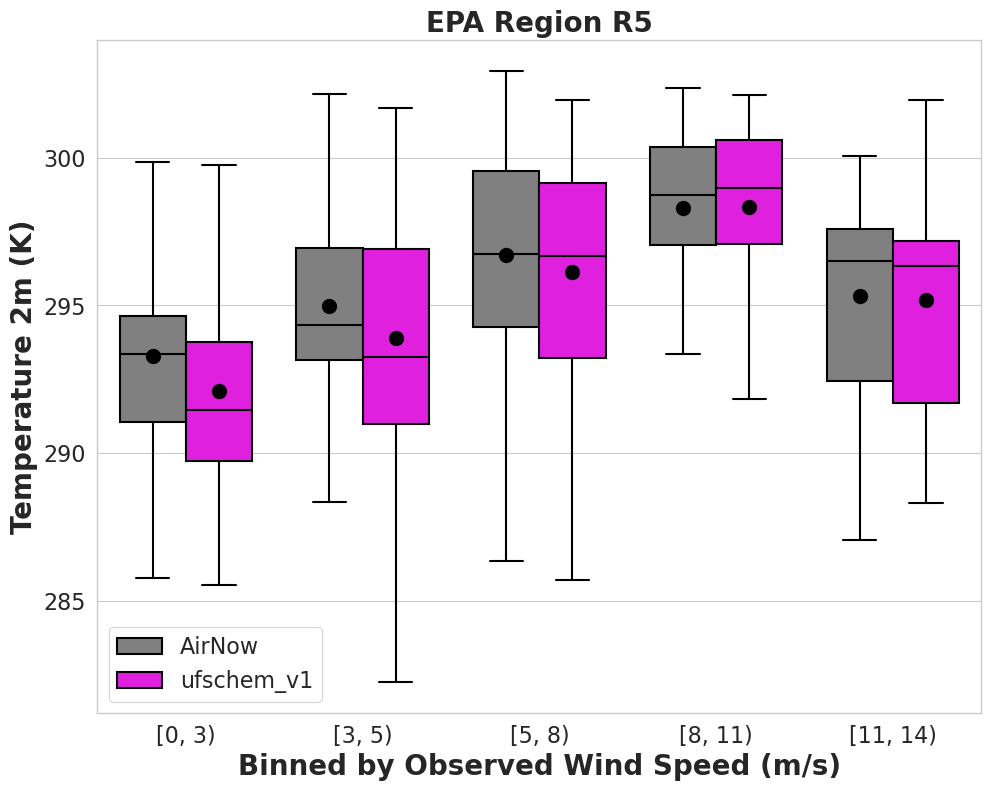

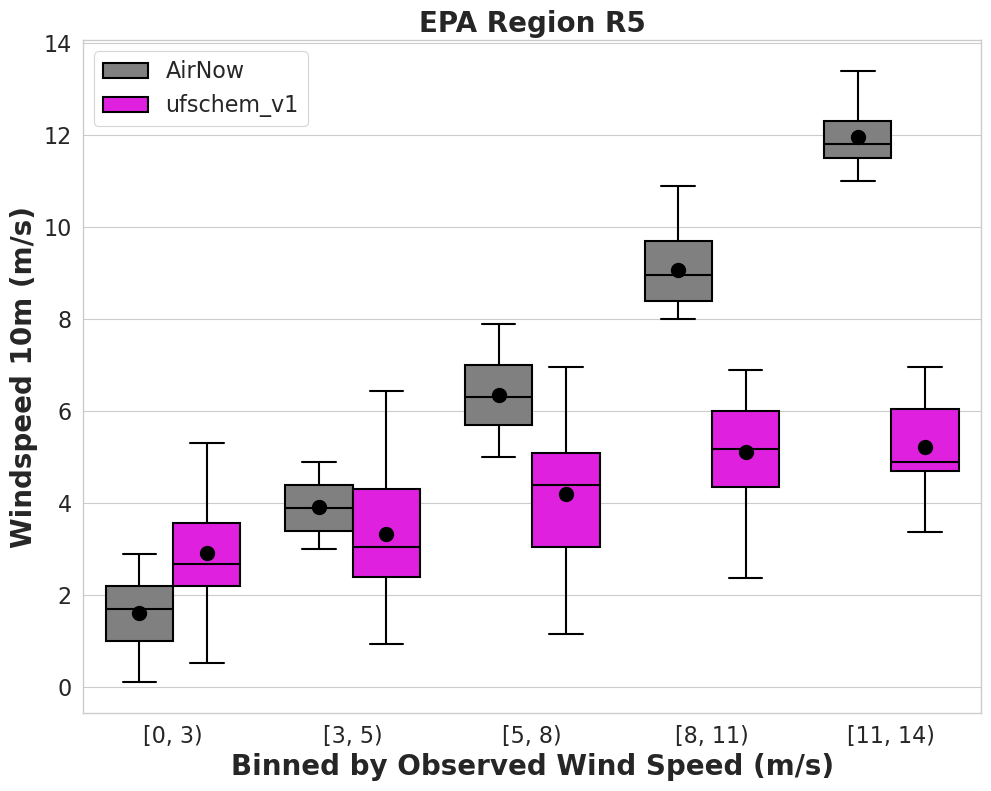

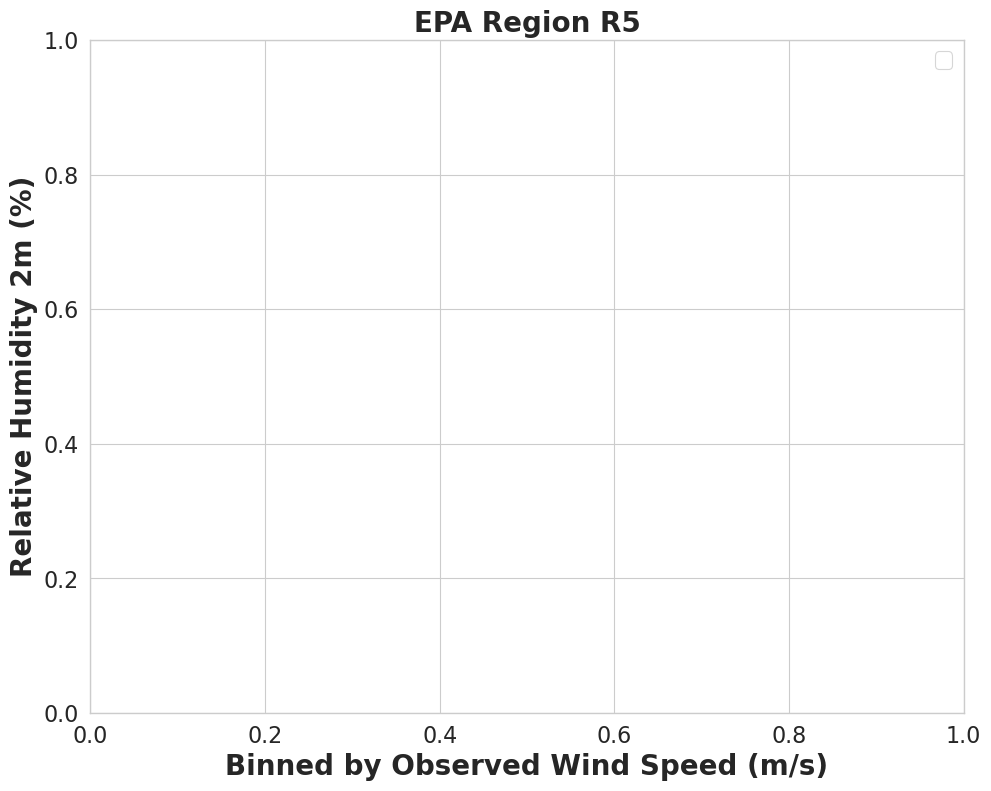

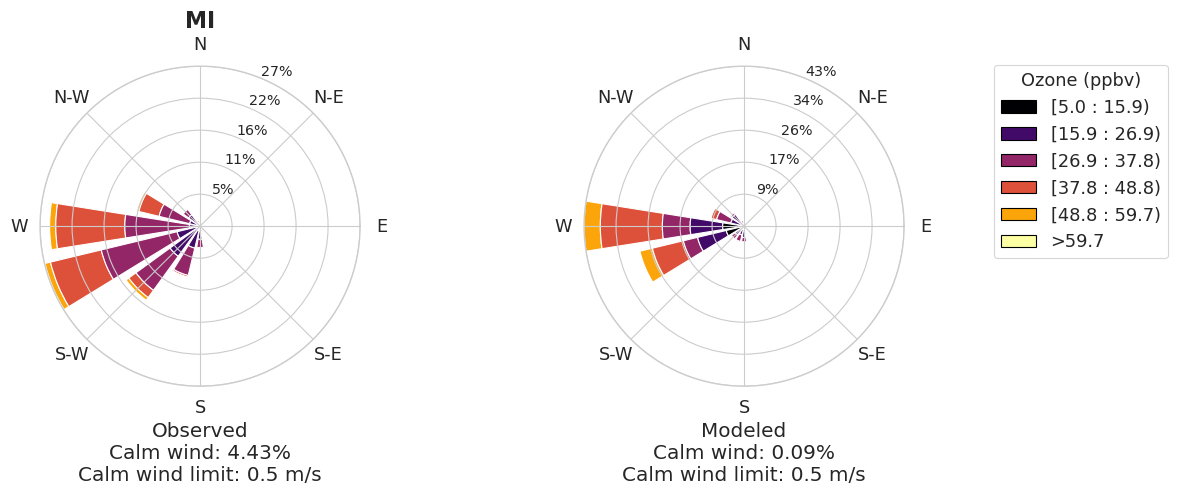

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.OZONE.2017-07-01_00.2017-07-03_00.siteid.260810020...


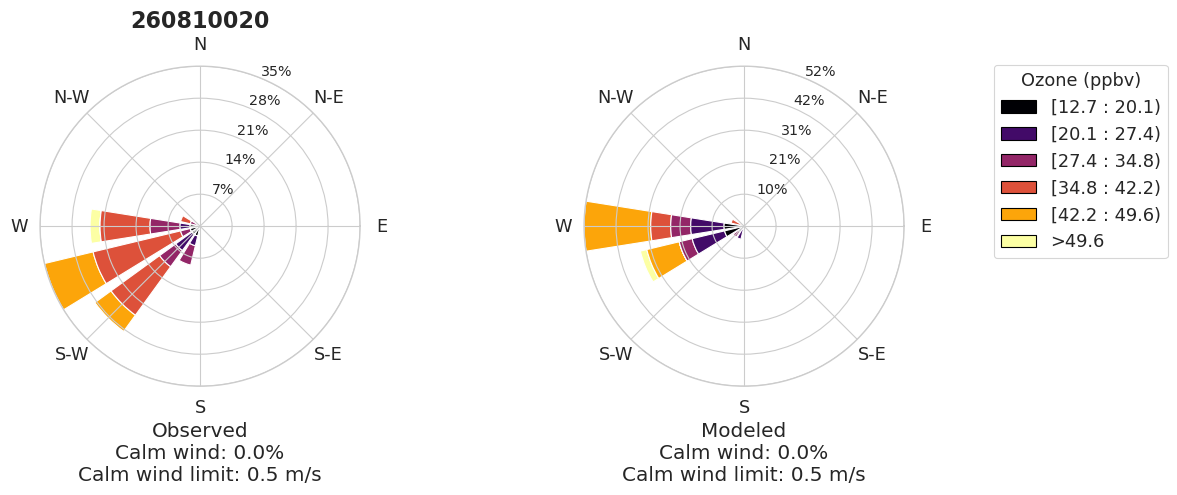

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.TEMP.2017-07-01_00.2017-07-03_00.state_name.MI...


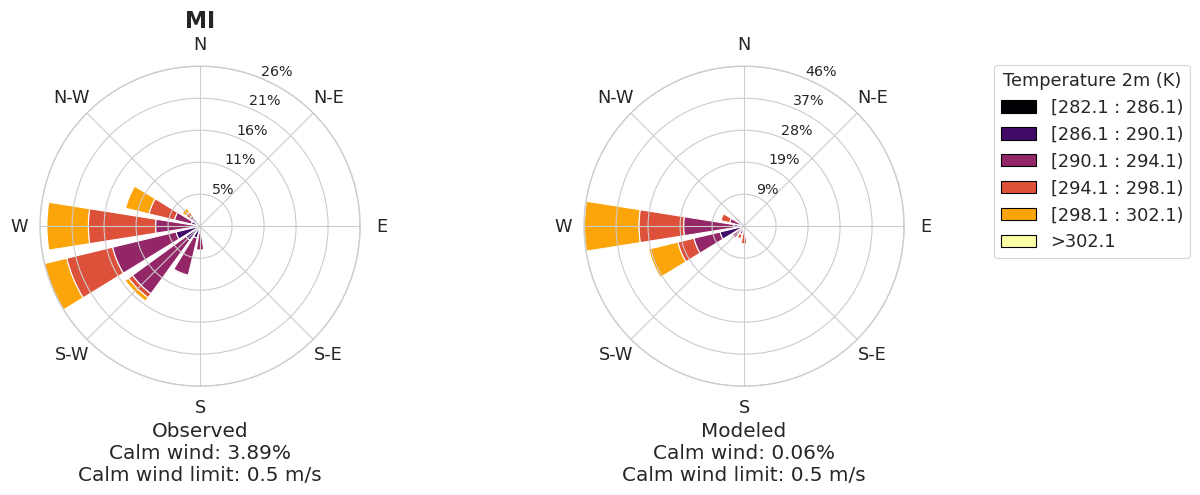

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.TEMP.2017-07-01_00.2017-07-03_00.siteid.260810020...


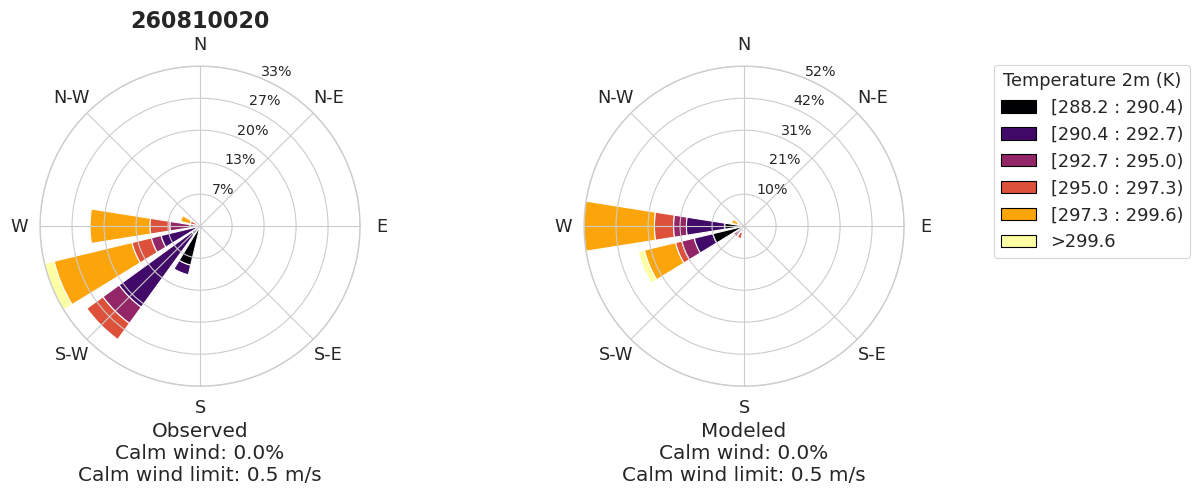

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.WS.2017-07-01_00.2017-07-03_00.state_name.MI...


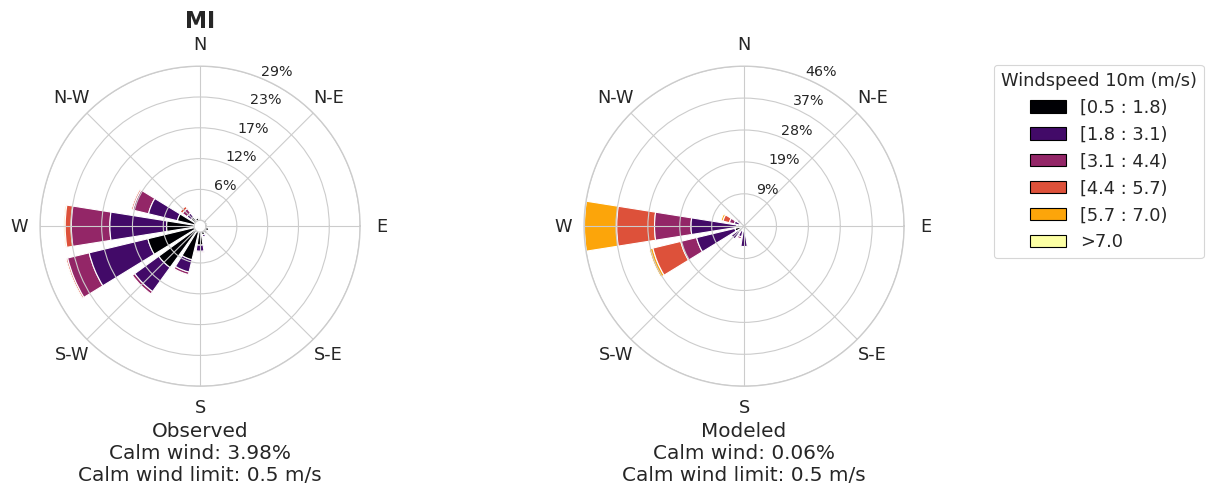

Saving rose plot to ./output/airnow_ufschem/plot_grp6.rose_plot.WS.2017-07-01_00.2017-07-03_00.siteid.260810020...


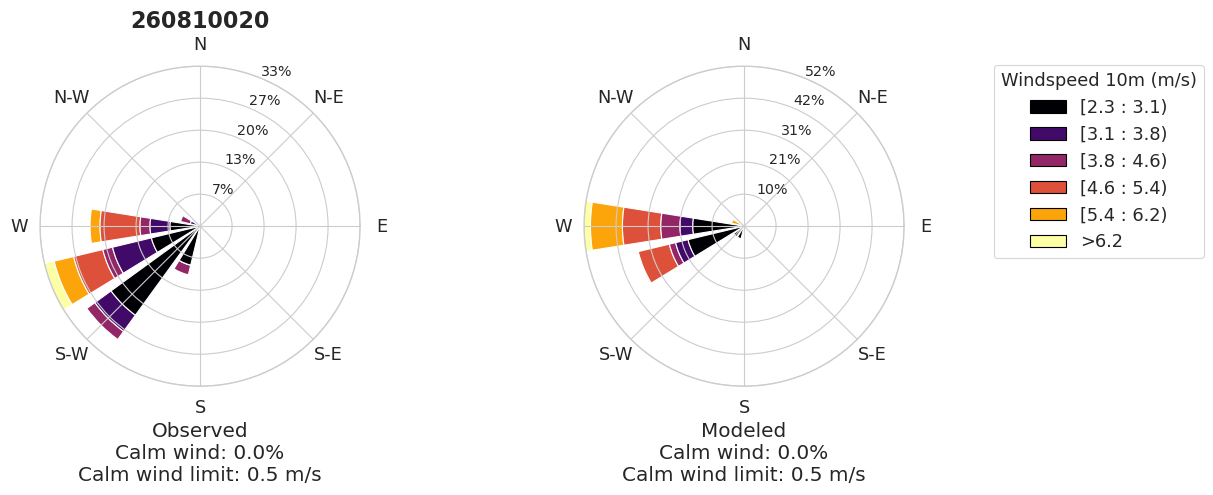

CPU times: user 1min 54s, sys: 3.99 s, total: 1min 58s
Wall time: 1min 57s


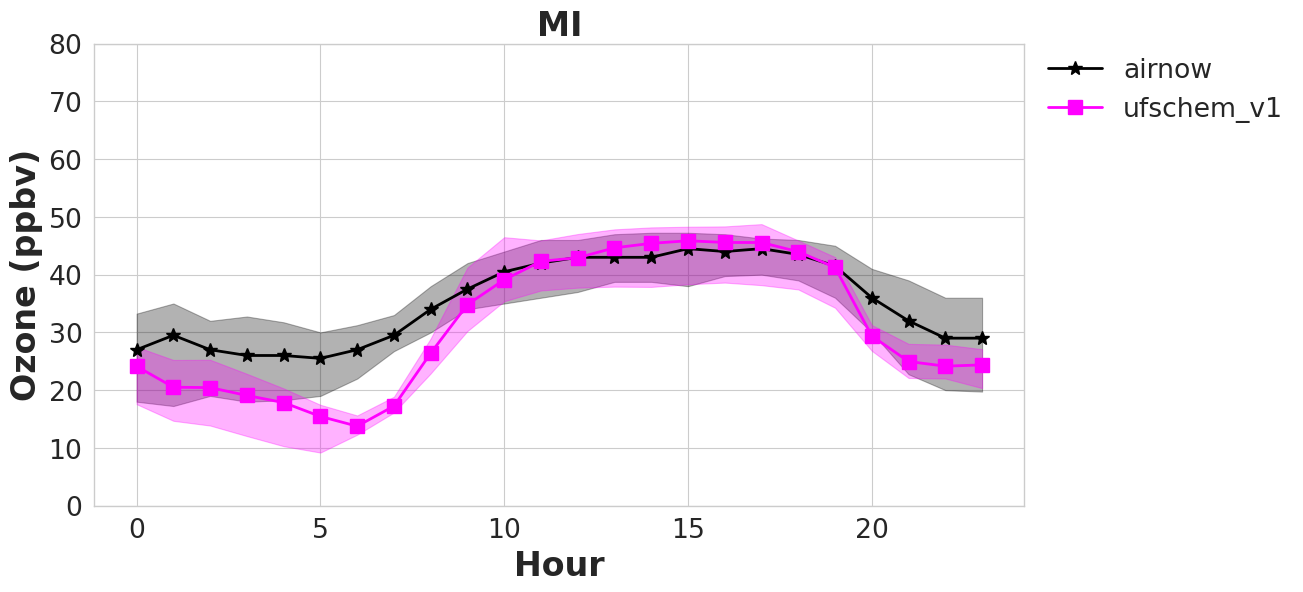

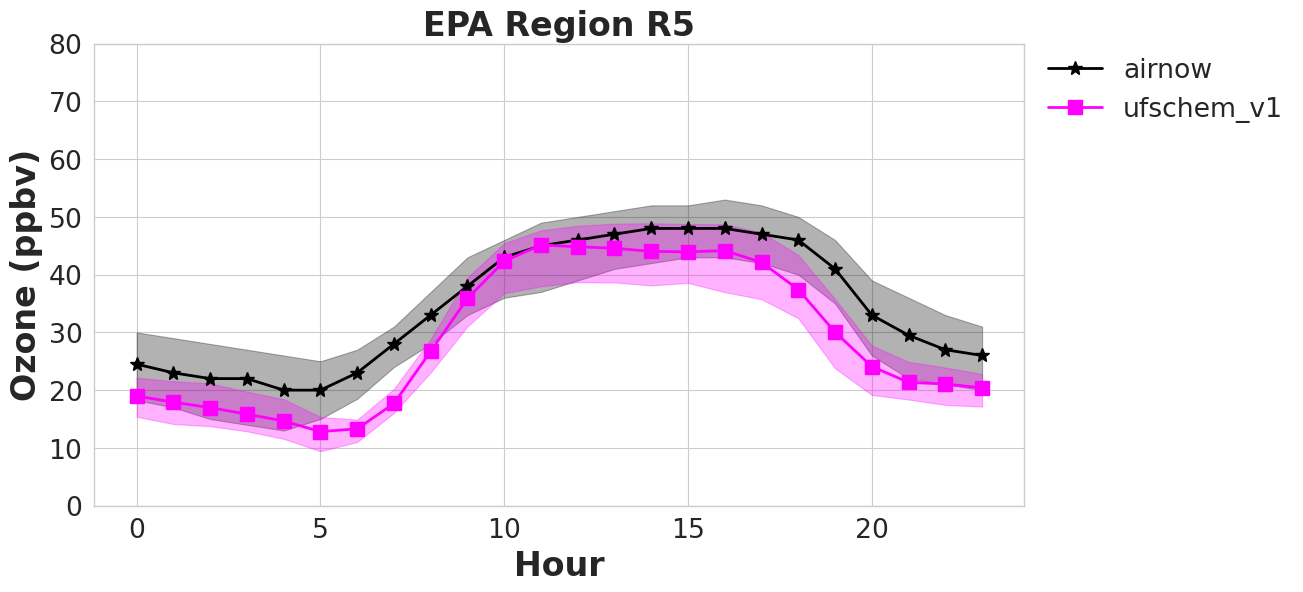

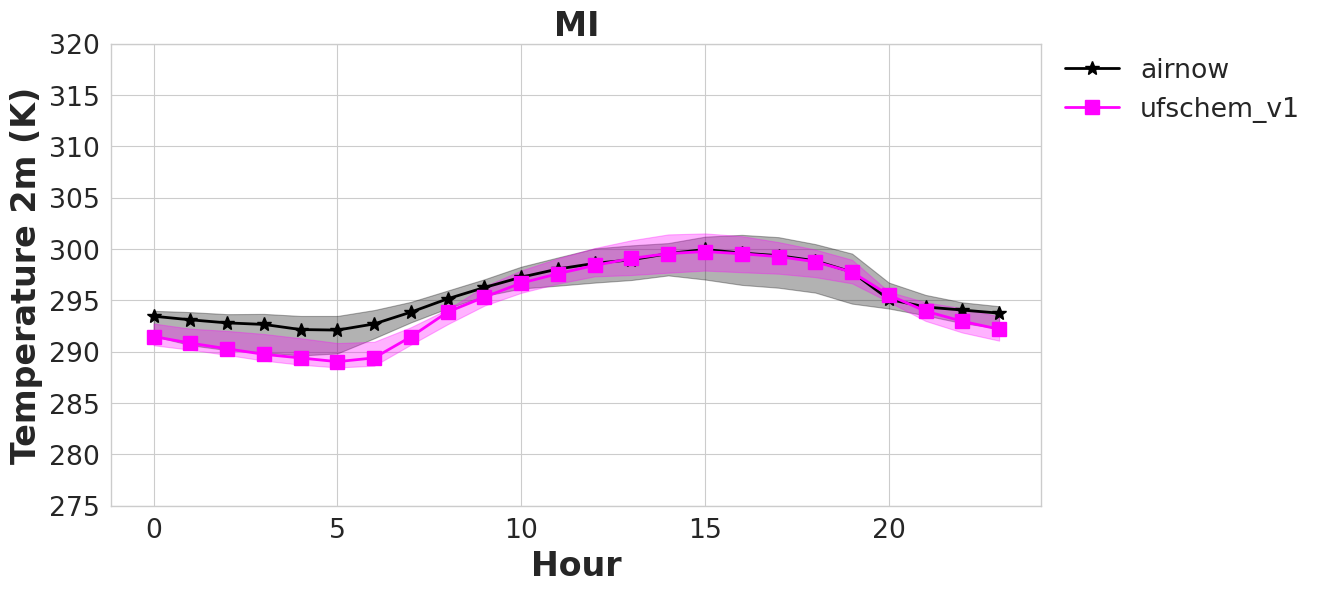

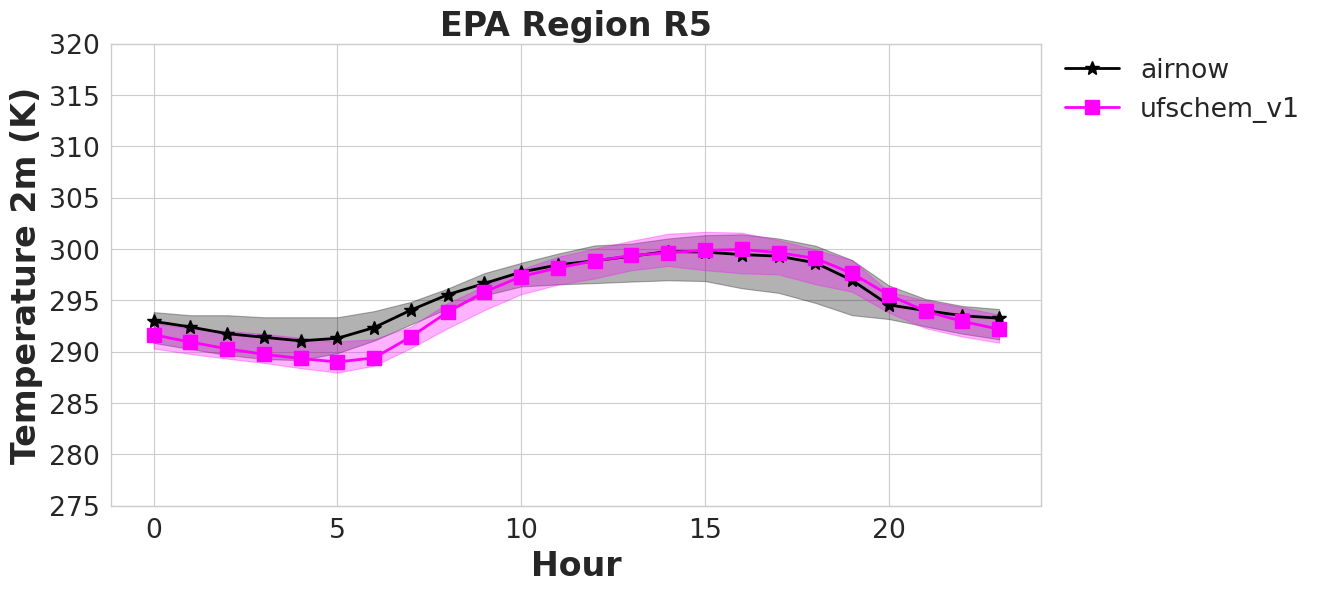

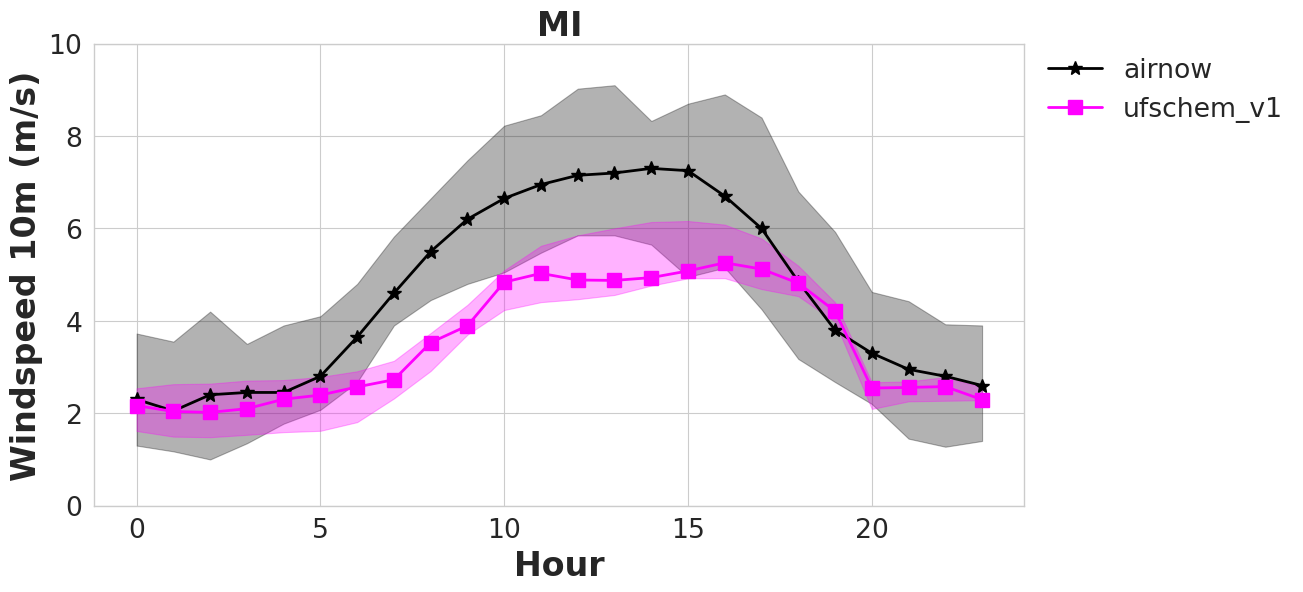

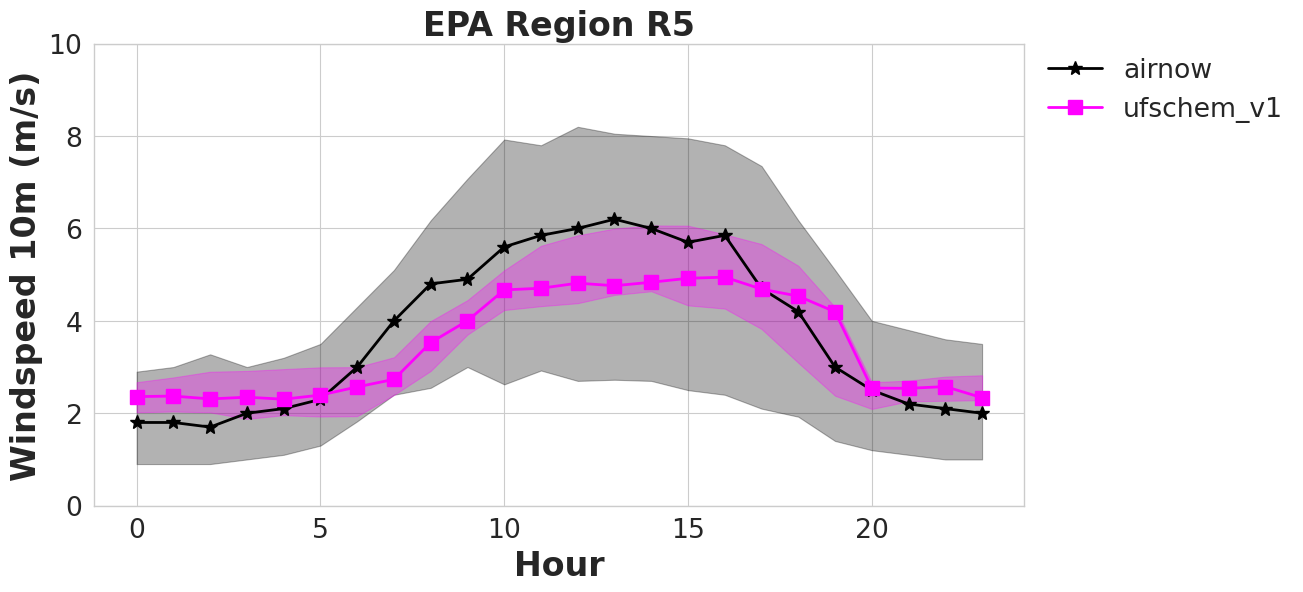

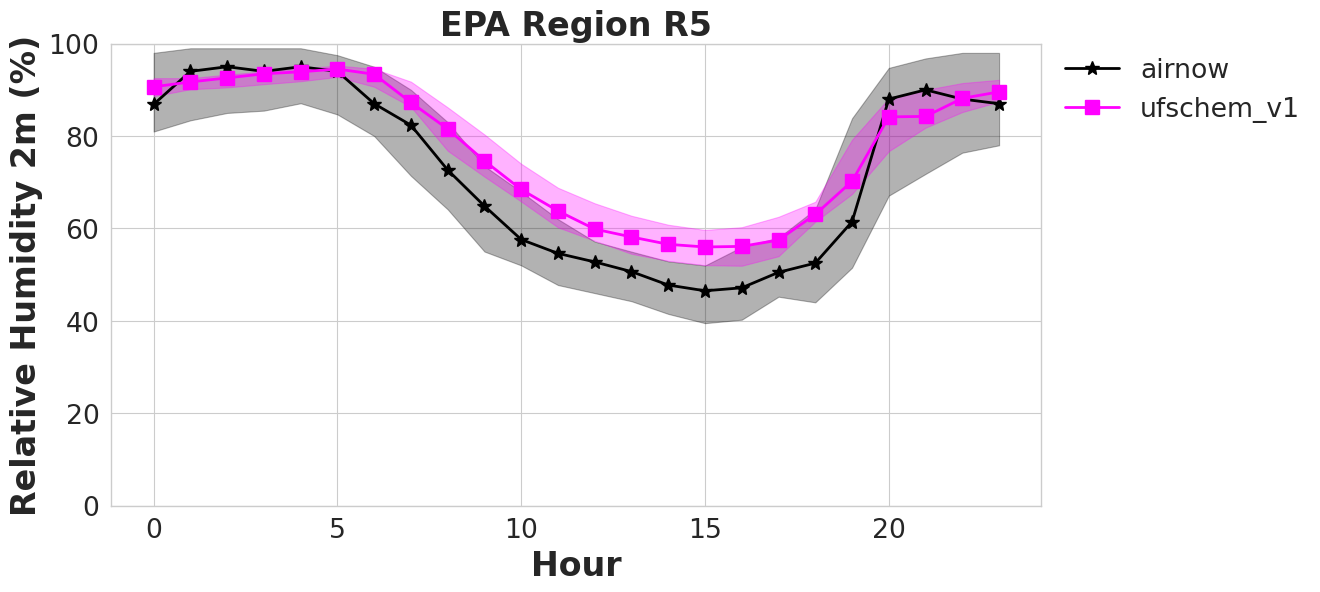

In [14]:
%%time

an.plotting()

CPU times: user 3.43 s, sys: 189 ms, total: 3.62 s
Wall time: 3.65 s


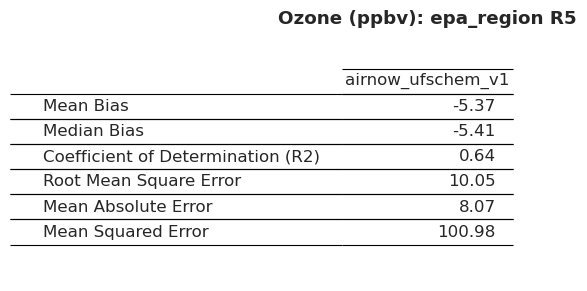

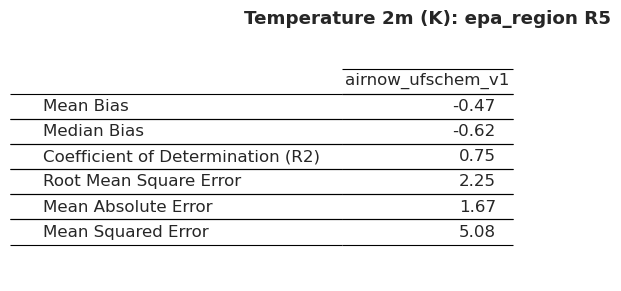

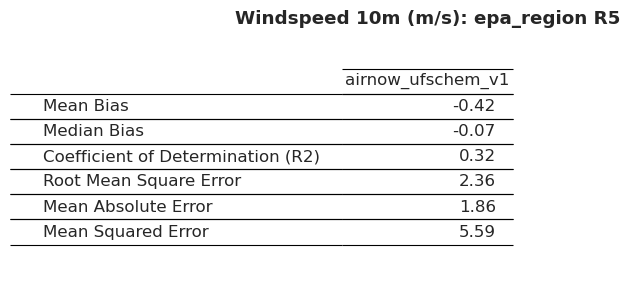

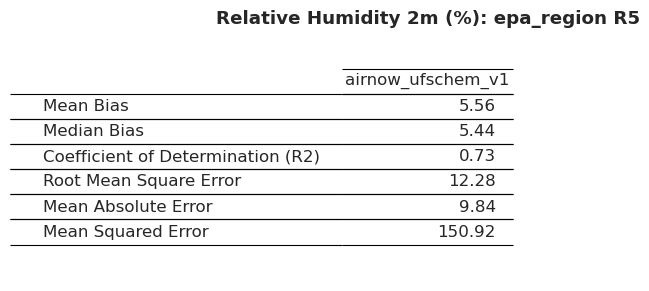

In [15]:
%%time

an.stats()